In [ ]:
# ==============================================================================
# FIX 1: Generate knova_topics.csv and knova_interests.csv
# (New cell, inserted immediately after Step 1, before Step 2)
# ==============================================================================
import pandas as pd
from datetime import datetime

print("Generating knova_topics.csv...")
# knova_topics.csv: export TOPIC_BANK dict
topics_data = []
for topic, tags in TOPIC_BANK.items():
    topics_data.append({
        'topic': topic,
        'tags': '|'.join(tags)
    })
df_topics = pd.DataFrame(topics_data)
df_topics.to_csv('knova_topics.csv', index=False)

print("Generating knova_interests.csv...")
# knova_interests.csv: per-user interests table from df_users
interests_data = []
current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
for _, user in df_users.iterrows():
    user_id = user['user_id']
    if pd.notna(user['interests']):
        for topic in user['interests'].split('|'):
            interests_data.append({
                'user_id': user_id,
                'topic': topic,
                'source': 'onboarding',
                'weight': 1.0,
                'added_at': current_time
            })
df_interests = pd.DataFrame(interests_data)
df_interests.to_csv('knova_interests.csv', index=False)

print(f"✅ knova_topics.csv: {len(df_topics)} topics | knova_interests.csv: {len(df_interests)} rows")

# Sanity check for knova_interests.csv
print("\nSanity check for knova_interests.csv (topics per user):")
interests_per_user = df_interests.groupby('user_id')['topic'].count()
print(interests_per_user.describe())
print(f"Min topics per user: {interests_per_user.min()}")
print(f"Max topics per user: {interests_per_user.max()}")

Generating knova_topics.csv...
Generating knova_interests.csv...
✅ knova_topics.csv: 97 topics | knova_interests.csv: 6992 rows

Sanity check for knova_interests.csv (topics per user):
count    2000.000000
mean        3.496000
std         1.114722
min         2.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: topic, dtype: float64
Min topics per user: 2
Max topics per user: 5


🧹 Starting Step 2: Preprocessing & Merging...
   Loaded: Users=2000, Content=10000, Interactions=59968
   ✅ Created 'creator_trust' from 'creator_followed'
✅ Step 2 Complete: Saved 'knova_cleaned.csv'


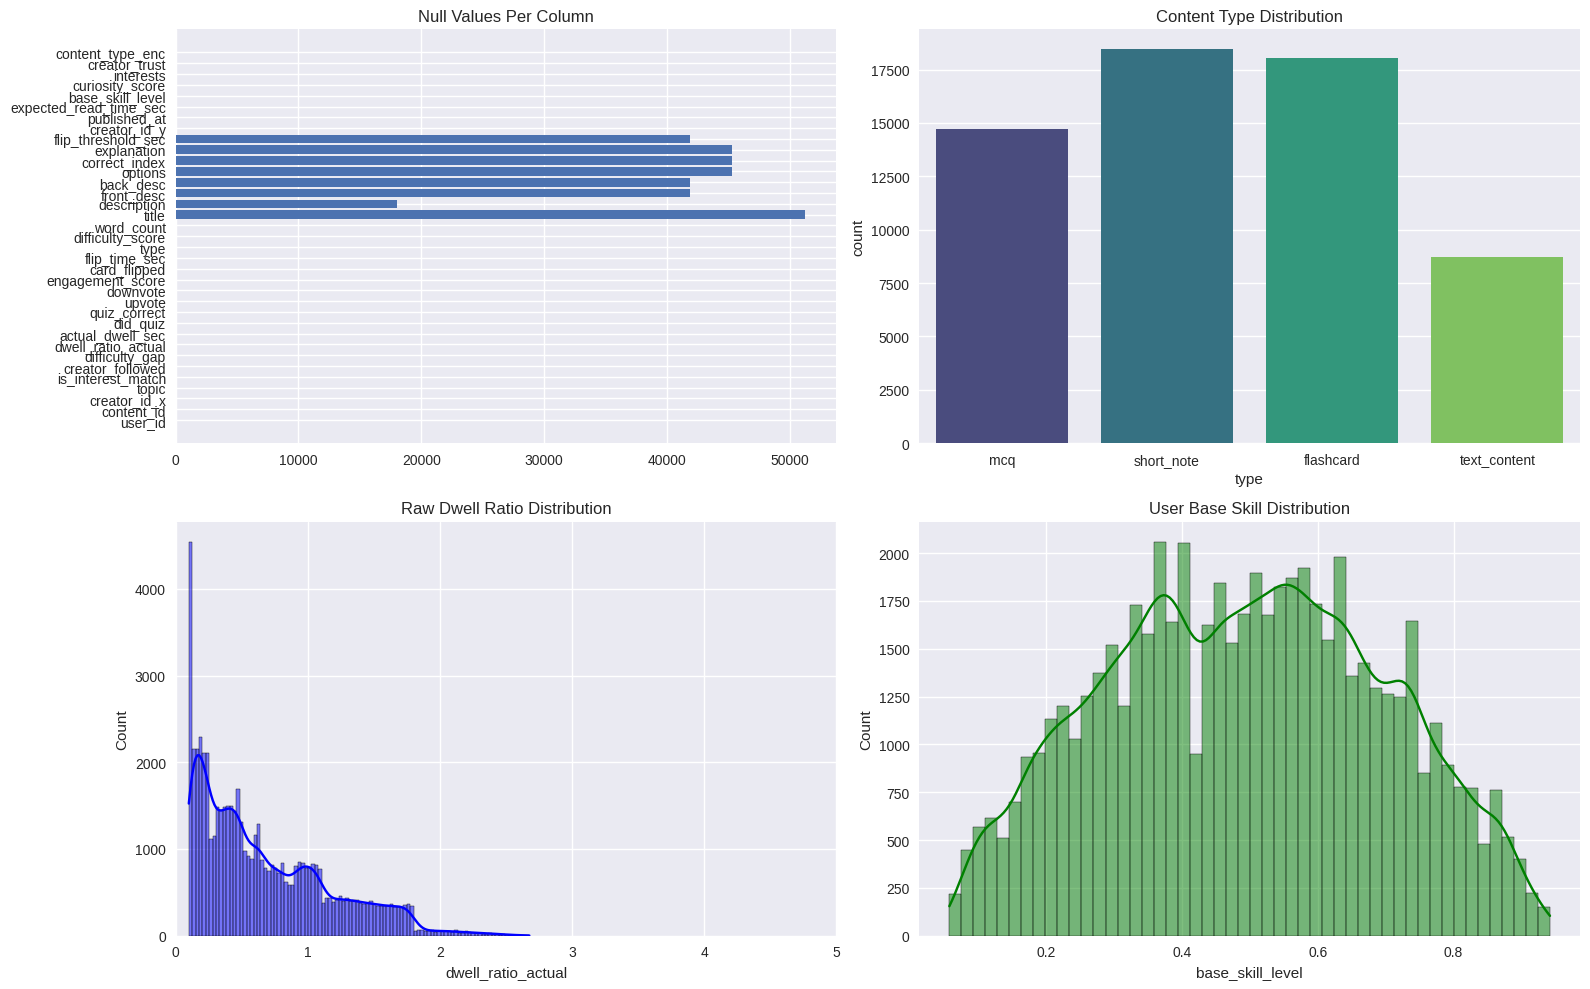

In [ ]:
# ==============================================================================
# STEP 2: PREPROCESSING & DATA MERGING
# ==============================================================================
!pip install pandas numpy scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print("🧹 Starting Step 2: Preprocessing & Merging...")

# 1. Load Raw Data
df_users = pd.read_csv('knova_users.csv')
df_content = pd.read_csv('knova_content.csv')
df_interactions = pd.read_csv('knova_interactions.csv')

print(f"   Loaded: Users={len(df_users)}, Content={len(df_content)}, Interactions={len(df_interactions)}")

# 2. Merge Datasets
# Ensure all interaction columns (like actual_dwell_sec) are kept
df = df_interactions.merge(df_content.drop(columns=['topic']), on='content_id', how='left')
df = df.merge(df_users[['user_id', 'base_skill_level', 'curiosity_score', 'interests']], on='user_id', how='left')

# 3. Handle Missing Values (Cold Start Strategy)
df['base_skill_level'] = df['base_skill_level'].fillna(0.5)
df['curiosity_score'] = df['curiosity_score'].fillna(0.5)
df['is_interest_match'] = df['is_interest_match'].fillna(0)

# --- FIX: Creator Trust Alias ---
if 'creator_followed' in df.columns and 'creator_trust' not in df.columns:
    df['creator_trust'] = df['creator_followed'].astype(float)
    print("   ✅ Created 'creator_trust' from 'creator_followed'")

# 4. Encode Categorical Variables
le_type = LabelEncoder()
df['content_type_enc'] = le_type.fit_transform(df['type'])
joblib.dump(le_type, 'knova_type_encoder.pkl')

# 5. Basic Outlier Clipping (Pre-Engineering)
# Now actual_dwell_sec is guaranteed to exist after the full merge
df['dwell_ratio_actual'] = df['dwell_ratio_actual'].clip(0.1, 5.0)
df['actual_dwell_sec'] = df['actual_dwell_sec'].clip(lower=0.1)

# 6. Save Cleaned Intermediate Data
df.to_csv('knova_cleaned.csv', index=False)
print("✅ Step 2 Complete: Saved 'knova_cleaned.csv'")

# ==============================================================================
# 📊 DIAGNOSTIC VISUALIZATIONS (Step 2)
# ==============================================================================
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

null_counts = df.isnull().sum()
axs[0, 0].barh(null_counts.index, null_counts.values)
axs[0, 0].set_title('Null Values Per Column')

sns.countplot(data=df, x='type', ax=axs[0, 1], palette='viridis')
axs[0, 1].set_title('Content Type Distribution')

sns.histplot(data=df, x='dwell_ratio_actual', bins=100, kde=True, ax=axs[1, 0], color='blue')
axs[1, 0].set_title('Raw Dwell Ratio Distribution')
axs[1, 0].set_xlim(0, 5)

sns.histplot(data=df, x='base_skill_level', bins=50, kde=True, ax=axs[1, 1], color='green')
axs[1, 1].set_title('User Base Skill Distribution')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

print("⚙  Starting Step 3: Refined Feature Engineering (Balanced Telemetry - NO LEAKAGE)...")

# 1. LOAD DATA
df = pd.read_csv('knova_cleaned.csv')

# Store original index to merge back after sorting for time-based features
df['original_index'] = df.index

# 2. DWELL & VELOCITY (KEEP THESE)
clip_limits = {'flashcard': 2.0, 'short_note': 2.2, 'mcq': 3.0, 'text_content': 2.5}
def clip_dwell_by_type(group):
    ctype = group['type'].iloc[0]
    upper = clip_limits.get(ctype, 2.5)
    group['dwell_ratio_actual'] = group['dwell_ratio_actual'].clip(0.1, upper)
    return group

df = df.groupby('type', group_keys=False).apply(clip_dwell_by_type)
df['dwell_norm_by_type'] = df.groupby('type')['dwell_ratio_actual'].transform(lambda x: (x - x.mean()) / x.std()).clip(-3, 3).fillna(0)

df['read_velocity_raw'] = df['word_count'] / df['actual_dwell_sec'].replace(0, np.nan)
df['read_velocity'] = df.groupby('type')['read_velocity_raw'].transform(lambda x: (x - x.mean()) / x.std()).clip(-3, 3).fillna(0)

# REMOVE: Leaky features (vote_signal, quiz_engagement, focus_ratio)
# 3. KNOWLEDGE & ALIGNMENT (KEEP THESE)
df['abs_difficulty_gap'] = df['difficulty_gap'].abs()

# Mastery score calculation (KEEP AS-IS per user request)
mastery = df[df['did_quiz'] == 1].groupby(['user_id', 'topic'])['quiz_correct'].agg(['mean']).reset_index()
mastery.columns = ['user_id', 'topic', 'mastery_score']
df = df.merge(mastery, on=['user_id', 'topic'], how='left')
df['mastery_score'] = df['mastery_score'].fillna(0.5)

df['depth_alignment'] = 1 - df['abs_difficulty_gap'].clip(0, 1)
df['kg_readiness'] = (df['mastery_score'] - df['difficulty_score']).clip(-1, 1)

# 4. ADD NEW HELD-OUT FEATURES: user_topic_upvote_rate and user_topic_interaction_count
# Calculate global upvote rate for cold start fallback
global_upvote_rate = df['upvote'].mean()

# Sort by user_id and original_index to ensure chronological order for expanding window
df = df.sort_values(by=['user_id', 'original_index']).reset_index(drop=True)

# Calculate user_topic_upvote_rate (mean of PAST upvotes for that user-topic)
# Shift by 1 to exclude the current interaction's upvote, then expand mean
df['shifted_upvote'] = df.groupby(['user_id', 'topic'])['upvote'].shift(1)
df['user_topic_upvote_rate'] = df.groupby(['user_id', 'topic'])['shifted_upvote'].expanding().mean().reset_index(level=[0,1], drop=True)
df['user_topic_upvote_rate'] = df['user_topic_upvote_rate'].fillna(global_upvote_rate)

# Calculate user_topic_interaction_count (count of PAST interactions for that user-topic)
# Shift by 1 to exclude the current interaction, then expand count
df['shifted_interaction'] = df.groupby(['user_id', 'topic'])['content_id'].shift(1) # shift any non-null column
df['user_topic_interaction_count'] = df.groupby(['user_id', 'topic'])['shifted_interaction'].expanding().count().reset_index(level=[0,1], drop=True)
df['user_topic_interaction_count'] = df['user_topic_interaction_count'].fillna(0)

# Drop temporary columns used for calculation
df = df.drop(columns=['shifted_upvote', 'shifted_interaction'])

# Restore original order after calculating expanding window features (important if subsequent steps rely on it)
df = df.sort_values(by='original_index').reset_index(drop=True).drop(columns=['original_index'])

# 5. SANITIZED TARGET (KEEP AS-IS PER USER REQUEST)
df['relevance'] = (
    (df['actual_dwell_sec'] >= df['expected_read_time_sec'] * 0.6).astype(int) * 1 +
    (df['upvote'] == 1).astype(int) * 1 +
    ((df['type'] == 'flashcard') & (df['card_flipped'] == 1)).astype(int) * 1
).clip(0, 3)

print("\nRelevance Distribution (Before Noise):")
print(df['relevance'].value_counts().sort_index())

# 6. ADD REALISTIC LABEL NOISE
np.random.seed(123) # Set separate seed for reproducibility of noise

# Randomly select ~15% of rows
num_rows_to_nudge = int(len(df) * 0.15)
nudge_indices = np.random.choice(df.index, size=num_rows_to_nudge, replace=False)

# Nudge relevance by +1 or -1
nudges = np.random.choice([-1, 1], size=num_rows_to_nudge)
df.loc[nudge_indices, 'relevance'] = df.loc[nudge_indices, 'relevance'] + nudges

# Clip to stay within [0, 3]
df['relevance'] = df['relevance'].clip(0, 3)

print("\nRelevance Distribution (After Noise):")
print(df['relevance'].value_counts().sort_index())

# 7. CONFIG
FEATURES_ALL = [
    'dwell_norm_by_type', 'read_velocity', 'mastery_score', 'kg_readiness',
    'depth_alignment', 'base_skill_level', 'curiosity_score', 'content_type_enc',
    'creator_trust', 'user_topic_upvote_rate', 'user_topic_interaction_count'
]
# topic_similarity and als_score will be added in Step 4, not here.

config = {'FEATURES_ALL': FEATURES_ALL, 'relevance_label': 'relevance'}
with open('knova_feature_config.json', 'w') as f: json.dump(config, f, indent=2)
df.to_csv('knova_features.csv', index=False)
print("✅ Saved Balanced Features (No Leakage)")

⚙  Starting Step 3: Refined Feature Engineering (Balanced Telemetry - NO LEAKAGE)...

Relevance Distribution (Before Noise):
relevance
0    30008
1    18525
2    10652
3      783
Name: count, dtype: int64

Relevance Distribution (After Noise):
relevance
0    29161
1    18742
2    10526
3     1539
Name: count, dtype: int64
✅ Saved Balanced Features (No Leakage)


In [ ]:
# ==============================================================================
# STEP 4a & 4b (FIXED + TAGS): RETRIEVAL MODELS (TF-IDF + ALS + TAG SIMILARITY)
# Fix: topic repeated 4x in content_text so it dominates the TF-IDF vector,
# instead of being diluted by the long generated description sentence.
# NEW: tag_similarity — deterministic topic-to-topic relatedness from
# knova_topic_tags.csv (Jaccard overlap), separate signal from lexical TF-IDF.
# ==============================================================================
!pip install implicit scikit-learn -q
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from implicit import als
import scipy.sparse as sparse
import joblib

print("🚀 Starting Step 4 (FIXED + TAGS): Retrieval Model Training...")

# Load Data
df_content = pd.read_csv('knova_content.csv')
df_users = pd.read_csv('knova_users.csv')
df = pd.read_csv('knova_features.csv')

# --- TF-IDF (FIXED: topic repeated 4x to dominate the vector) ---
print("   📝 Training TF-IDF (topic-weighted)...")
df_content['content_text'] = (
    (df_content['topic'].fillna('') + ' ') * 4 +   # <-- FIX: repeat topic 4x
    df_content['type'].fillna('') + ' ' +
    df_content['title'].fillna('') + ' ' +
    df_content['description'].fillna('')
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english', min_df=2)
tfidf_matrix = tfidf.fit_transform(df_content['content_text'])
joblib.dump(tfidf, 'knova_tfidf.pkl')
joblib.dump(tfidf_matrix, 'knova_tfidf_matrix.pkl')
joblib.dump(df_content['content_id'].values, 'knova_content_ids.pkl')
print(f"   ✅ TF-IDF trained: {tfidf_matrix.shape}")

# Generate topic_similarity
content_id_to_idx = {cid: idx for idx, cid in enumerate(df_content['content_id'].values)}

# Load knova_interests.csv to build user interest vectors
df_interests = pd.read_csv('knova_interests.csv')

user_vectors = {}
# Build user interest vectors from knova_interests.csv, weighting topics by 'weight' column
for user_id, group_interests in df_interests.groupby('user_id'):
    topic_list_for_user = []
    for _, row in group_interests.iterrows():
        topic = row['topic']
        weight = row['weight']

        # Repeat topic round(weight * 3) times, minimum 1 repeat
        num_repeats = max(1, int(round(weight * 3)))
        topic_list_for_user.extend([topic] * num_repeats)

    user_interest_string = ' '.join(topic_list_for_user)
    user_vectors[user_id] = tfidf.transform([user_interest_string])

topic_sims = []
for _, row in df.iterrows():
    idx = content_id_to_idx.get(row['content_id'])
    uid = row['user_id']
    if idx is None or uid not in user_vectors:
        topic_sims.append(0.0)
        continue
    sim = cosine_similarity(user_vectors[uid], tfidf_matrix[idx])[0][0]
    topic_sims.append(round(float(sim), 4))

old_mean = 0.0213  # from your original run, for comparison
df['topic_similarity'] = topic_sims
new_mean = df['topic_similarity'].mean()
print(f"\n   📊 topic_similarity distribution comparison:")
print(f"      OLD mean (pre-fix): {old_mean:.4f}")
print(f"      NEW mean:           {new_mean:.4f}")
print(f"      NEW min/max/std:    {df['topic_similarity'].min():.4f} / "
      f"{df['topic_similarity'].max():.4f} / {df['topic_similarity'].std():.4f}")

# --- DIAGNOSTIC: matching vs non-matching content for a sample of users ---
print("\n   🔍 Matching vs non-matching content similarity (sample of 5 users):")
sample_users = df_users['user_id'].unique()[:5]
for uid in sample_users:
    user_row = df_users[df_users['user_id'] == uid].iloc[0]
    interests = set(user_row['interests'].split('|'))
    if uid not in user_vectors:
        continue

    matching_content = df_content[df_content['topic'].isin(interests)].sample(
        min(3, len(df_content[df_content['topic'].isin(interests)])), random_state=42)
    non_matching_content = df_content[~df_content['topic'].isin(interests)].sample(3, random_state=42)

    match_sims = [
        round(float(cosine_similarity(user_vectors[uid], tfidf_matrix[content_id_to_idx[cid]])[0][0]), 4)
        for cid in matching_content['content_id']
    ]
    non_match_sims = [
        round(float(cosine_similarity(user_vectors[uid], tfidf_matrix[content_id_to_idx[cid]])[0][0]), 4)
        for cid in non_matching_content['content_id']
    ]
    print(f"   User {uid} | Matching topics sims: {match_sims} | Non-matching sims: {non_match_sims}")

print(f"\n   ✅ topic_similarity generated")

# ==============================================================================
# NEW: TAG_SIMILARITY — deterministic topic-to-topic relatedness (Jaccard on tags)
# Independent of TF-IDF wording; catches curated relationships like
# History of Nepal <-> Cultural Tourism that share zero literal keywords.
# ==============================================================================
print("\n   🏷️  Computing tag_similarity (topic-to-topic Jaccard)...")

# Load the tag table saved in Step 1 — metadata only, never touches content_text
df_topic_tags = pd.read_csv('knova_topic_tags.csv')
topic_tag_sets = {row['topic']: set(row['tags'].split('|')) for _, row in df_topic_tags.iterrows()}
all_topics = list(topic_tag_sets.keys())

def jaccard(set_a, set_b):
    # Intersection over union of two tag sets; 0.0 if either is empty
    union = len(set_a | set_b)
    return len(set_a & set_b) / union if union else 0.0

# Precompute the full topic x topic similarity matrix once (89x89, cheap)
tag_sim_lookup = {
    t1: {t2: jaccard(topic_tag_sets[t1], topic_tag_sets[t2]) for t2 in all_topics}
    for t1 in all_topics
}

# Map each user to their raw set of interest topics (from onboarding + promoted)
user_interest_topics = {
    row['user_id']: set(row['interests'].split('|'))
    for _, row in df_users.iterrows()
}

def get_tag_similarity(user_id, candidate_topic):
    # Max Jaccard between the candidate topic and ANY of the user's interest topics
    interests = user_interest_topics.get(user_id)
    if not interests or candidate_topic not in tag_sim_lookup:
        return 0.0
    return max((tag_sim_lookup[candidate_topic].get(t, 0.0) for t in interests), default=0.0)

# Compute on unique (user_id, topic) pairs only, then merge back — much faster than
# recomputing per-row when the same user/topic combo repeats across many interactions
unique_pairs = df[['user_id', 'topic']].drop_duplicates().copy()
unique_pairs['tag_similarity'] = unique_pairs.apply(
    lambda r: get_tag_similarity(r['user_id'], r['topic']), axis=1
)
df = df.merge(unique_pairs, on=['user_id', 'topic'], how='left')

print(f"   ✅ tag_similarity generated (Mean: {df['tag_similarity'].mean():.4f}, "
      f"Min/Max: {df['tag_similarity'].min():.4f} / {df['tag_similarity'].max():.4f})")

# --- DIAGNOSTIC: confirm tag_similarity catches what TF-IDF misses (Nepal example) ---
print("\n   🔍 Cross-check — TF-IDF vs Tag similarity on curated-relation pairs:")
check_pairs = [
    ("History of Nepal", "Cultural Tourism"),
    ("AI", "Machine Learning"),
    ("History of Nepal", "Fluid Mechanics"),
]
for topic_a, topic_b in check_pairs:
    tag_sim = tag_sim_lookup.get(topic_a, {}).get(topic_b, 0.0)
    print(f"   {topic_a:<20} ↔ {topic_b:<20} | tag_similarity: {tag_sim:.4f}")

# --- Sanity check: flag any topic in df that has no tag data (would silently score 0.0) ---
topics_without_tags = set(df['topic'].unique()) - set(all_topics)
if topics_without_tags:
    print(f"   ⚠️ Topics with no TOPIC_TAGS entry (scoring 0.0 always): {topics_without_tags}")
else:
    print("   ✅ Every topic in the dataset has tag coverage")

# --- ALS (unchanged) ---
print("   🤝 Training ALS Collaborative Filtering...")
df['interaction_strength'] = (
    df['dwell_ratio_actual'] * 0.5 +
    df['upvote'] * 0.3 +
    df['did_quiz'] * 0.2
).clip(0, 1)

user_cat = df['user_id'].astype('category')
content_cat = df['content_id'].astype('category')
interaction_matrix = sparse.csr_matrix((
    df['interaction_strength'].values,
    (user_cat.cat.codes, content_cat.cat.codes)
))

model_als = als.AlternatingLeastSquares(factors=50, regularization=0.1, iterations=30, random_state=42)
model_als.fit(interaction_matrix)

joblib.dump(model_als, 'knova_als.pkl')
joblib.dump(user_cat.cat.categories, 'knova_als_user_ids.pkl')
joblib.dump(content_cat.cat.categories, 'knova_als_content_ids.pkl')
print("   ✅ ALS trained")

# Generate als_score
user_factors = model_als.user_factors
item_factors = model_als.item_factors
df['als_score'] = [
    float(user_factors[u] @ item_factors[c])
    for u, c in zip(user_cat.cat.codes, content_cat.cat.codes)
]
df['als_score'] = df['als_score'].clip(df['als_score'].quantile(0.01), df['als_score'].quantile(0.99))
print(f"   ✅ als_score generated (Mean: {df['als_score'].mean():.4f})")

# Save Final Features
df.to_csv('knova_features_final.csv', index=False)
print("✅ Step 4 (FIXED + TAGS) Complete: Saved knova_features_final.csv")
print(f"   New column added: tag_similarity (alongside existing topic_similarity, als_score)")
print("\n⚠️  NEXT: re-run Step 3B (similarity_weighted_engagement), then Step 5 (add tag_similarity to FEATURES_ALL, retrain ranker)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 27.1 MB/s eta 0:00:00
🚀 Starting Step 4 (FIXED + TAGS): Retrieval Model Training...
   📝 Training TF-IDF (topic-weighted)...
   ✅ TF-IDF trained: (10000, 5000)

   📊 topic_similarity distribution comparison:
      OLD mean (pre-fix): 0.0213
      NEW mean:           0.0190
      NEW min/max/std:    0.0000 / 0.9005 / 0.0901

   🔍 Matching vs non-matching content similarity (sample of 5 users):
   User 1 | Matching topics sims: [0.5014, 0.5628, 0.3289] | Non-matching sims: [0.0, 0.0, 0.0]
   User 2 | Matching topics sims: [0.5711, 0.5711, 0.5711] | Non-matching sims: [0.0, 0.0, 0.0]
   User 3 | Matching topics sims: [0.5352, 0.4524, 0.5466] | Non-matching sims: [0.0, 0.0, 0.0]
   User 4 | Matching topics sims: [0.4074, 0.3705, 0.3619] | Non-matching sims: [0.0, 0.0, 0.0]
   User 5 | Matching topics sims: [0.5561, 0.3606, 0.4111] | Non-matching sims: [0.0, 0.0, 0.0]

   ✅ topic_similarity generated

   🏷️  Computing tag_similarity (to

  0%|          | 0/30 [00:00<?, ?it/s]

   ✅ ALS trained
   ✅ als_score generated (Mean: 0.0468)
✅ Step 4 (FIXED + TAGS) Complete: Saved knova_features_final.csv
   New column added: tag_similarity (alongside existing topic_similarity, als_score)

⚠️  NEXT: re-run Step 3B (similarity_weighted_engagement), then Step 5 (add tag_similarity to FEATURES_ALL, retrain ranker)


In [ ]:
# ==============================================================================
# STEP 3B: SIMILARITY-WEIGHTED TOPIC ENGAGEMENT
# (Run this AFTER Step 4 - requires the trained TF-IDF matrix)
# No logic changes needed here — this step only adds one new column and
# never drops existing ones, so tag_similarity from Step 4 passes through intact.
# ==============================================================================
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

print("🔗 Starting Step 3B: Similarity-Weighted Topic Engagement...")

# 1. LOAD ARTIFACTS FROM STEP 4
df = pd.read_csv('knova_features_final.csv')
tfidf_matrix = joblib.load('knova_tfidf_matrix.pkl')          # (n_content, n_tfidf_features), sparse
content_ids = joblib.load('knova_content_ids.pkl')            # array aligned with tfidf_matrix rows
content_id_to_idx = {cid: idx for idx, cid in enumerate(content_ids)}

# NEW: confirm tag_similarity survived the Step 4 -> Step 3B handoff before proceeding
assert 'tag_similarity' in df.columns, "❌ tag_similarity missing — re-run Step 4 before Step 3B"
print(f"   ✅ tag_similarity present (Mean: {df['tag_similarity'].mean():.4f}) — carrying through unchanged")

global_upvote_rate = df['upvote'].mean()
print(f"   Global fallback upvote rate (cold start): {global_upvote_rate:.4f}")

# 2. BUILD PER-USER HISTORY: {user_id: (array_of_content_indices, array_of_upvotes)}
print("   Building per-user interaction history...")
user_history = {}
for uid, group in df.groupby('user_id'):
    idxs = group['content_id'].map(content_id_to_idx).dropna().astype(int).values
    upvotes = group.loc[group['content_id'].map(content_id_to_idx).notna(), 'upvote'].values
    user_history[uid] = (idxs, upvotes)

# 3. COMPUTE SIMILARITY-WEIGHTED ENGAGEMENT PER ROW
# For efficiency: for each user, compute similarity between ALL their past items
# ONCE (a small matrix, since a user has ~15-85 interactions), then reuse it for
# every row belonging to that user instead of recomputing per-row.
print("   Computing similarity-weighted engagement (this may take a few minutes)...")

similarity_weighted_scores = np.full(len(df), np.nan)

# Group row indices by user so we only do the expensive similarity computation once per user
df_reset = df.reset_index(drop=True)
grouped = df_reset.groupby('user_id').indices  # {user_id: array of row positions in df_reset}

for uid, row_positions in tqdm(grouped.items(), desc="Users processed"):
    hist_idxs, hist_upvotes = user_history.get(uid, (np.array([]), np.array([])))

    if len(hist_idxs) < 2:
        # Not enough history to compute meaningful similarity - use cold start fallback
        similarity_weighted_scores[row_positions] = global_upvote_rate
        continue

    # Get TF-IDF vectors for this user's full history (small matrix, e.g. 15-85 rows)
    hist_vectors = tfidf_matrix[hist_idxs]

    for pos in row_positions:
        content_id = df_reset.loc[pos, 'content_id']
        current_idx = content_id_to_idx.get(content_id)
        if current_idx is None:
            similarity_weighted_scores[pos] = global_upvote_rate
            continue

        current_vector = tfidf_matrix[current_idx]

        # Cosine similarity between current item and ALL of user's past items
        sims = cosine_similarity(current_vector, hist_vectors)[0]

        # LEAVE-ONE-OUT: zero out similarity to itself if this exact content_id
        # appears in the user's own history (avoids trivial self-leakage)
        self_mask = (hist_idxs == current_idx)
        sims = sims.copy()
        sims[self_mask] = 0.0

        sim_sum = sims.sum()
        if sim_sum < 1e-9:
            # No meaningful similarity to any past item - fall back
            similarity_weighted_scores[pos] = global_upvote_rate
        else:
            weights = sims / sim_sum
            similarity_weighted_scores[pos] = np.dot(weights, hist_upvotes)

df_reset['similarity_weighted_engagement'] = similarity_weighted_scores
df_reset['similarity_weighted_engagement'] = df_reset['similarity_weighted_engagement'].fillna(global_upvote_rate)

# 4. SAVE BACK
df_reset.to_csv('knova_features_final.csv', index=False)
print("✅ Step 3B Complete: 'similarity_weighted_engagement' added to knova_features_final.csv")

# NEW: final confirmation both new/old similarity signals are intact in the saved file
print(f"   Columns present: tag_similarity ✅ | topic_similarity ✅ | similarity_weighted_engagement ✅"
      if all(c in df_reset.columns for c in ['tag_similarity', 'topic_similarity', 'similarity_weighted_engagement'])
      else "   ⚠️ One or more similarity columns missing — check Step 4 output")

# 5. VERIFICATION: compare exact-match vs similarity-weighted for a few users
print("\n🔍 Comparison — exact-topic match vs. similarity-weighted engagement:")
sample_users = df_reset['user_id'].unique()[:5]
comparison = df_reset[df_reset['user_id'].isin(sample_users)].groupby('user_id').agg(
    user_topic_upvote_rate=('user_topic_upvote_rate', 'mean'),
    similarity_weighted_engagement=('similarity_weighted_engagement', 'mean'),
    n_interactions=('content_id', 'count')
).round(4)
print(comparison)
print("\n(Differences here show cases where similarity-based signal picks up")
print(" cross-topic patterns that exact topic-matching would miss entirely.)")

🔗 Starting Step 3B: Similarity-Weighted Topic Engagement...
   ✅ tag_similarity present (Mean: 0.1322) — carrying through unchanged
   Global fallback upvote rate (cold start): 0.0925
   Building per-user interaction history...
   Computing similarity-weighted engagement (this may take a few minutes)...


Users processed: 100%|██████████| 2000/2000 [00:56<00:00, 35.51it/s]


✅ Step 3B Complete: 'similarity_weighted_engagement' added to knova_features_final.csv
   Columns present: tag_similarity ✅ | topic_similarity ✅ | similarity_weighted_engagement ✅

🔍 Comparison — exact-topic match vs. similarity-weighted engagement:
         user_topic_upvote_rate  similarity_weighted_engagement  \
user_id                                                           
1                        0.0685                          0.1017   
2                        0.0832                          0.1639   
3                        0.0818                          0.0545   
4                        0.1265                          0.1808   
5                        0.1088                          0.0869   

         n_interactions  
user_id                  
1                    27  
2                    20  
3                    26  
4                    24  
5                    33  

(Differences here show cases where similarity-based signal picks up
 cross-topic patterns that ex

፦ Step 5: Training Leakage-Free Knova Ranker (with Similarity-Weighted Engagement + Tag Similarity)...

Relevance distribution:
relevance
0    29161
1    18742
2    10526
3     1539
Name: count, dtype: int64
Training until validation scores don't improve for 50 rounds
[50]	valid_0's ndcg@5: 0.844481	valid_0's ndcg@10: 0.885322	valid_0's ndcg@20: 0.912658
Early stopping, best iteration is:
[11]	valid_0's ndcg@5: 0.846545	valid_0's ndcg@10: 0.885304	valid_0's ndcg@20: 0.913175

። FULL EVALUATION (Leakage-Free + Similarity-Weighted Engagement + Tag Similarity):
   NDCG@10: 0.9150 | Prec@10: 0.9095 | Engagement: 0.1337
   (Published production benchmarks: NDCG@10 typically 0.85-0.91)

📊 Feature Contribution (%):
                       feature  importance_pct
            dwell_norm_by_type           24.49
                  kg_readiness           14.52
               depth_alignment           13.93
similarity_weighted_engagement           10.41
                 read_velocity           10.26


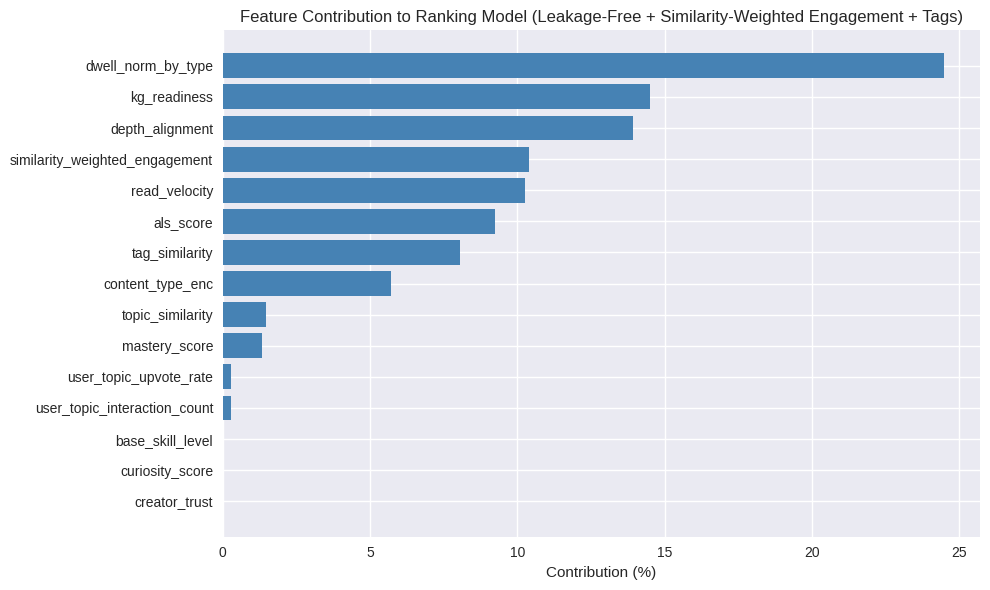


✅ Step 5 Complete: Model, scaler, and feature importance saved (tag_similarity now a first-class feature)


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import RobustScaler
import joblib, json
import matplotlib.pyplot as plt

print("፦ Step 5: Training Leakage-Free Knova Ranker (with Similarity-Weighted Engagement + Tag Similarity)...")

df = pd.read_csv('knova_features_final.csv')

# --- DEFENSIVE FALLBACKS (only trigger if an earlier step's output is missing) ---
# This handles cases where intermediate files might not be present or are incomplete.
if 'user_topic_upvote_rate' not in df.columns:
    print("   ⚠️ user_topic_upvote_rate missing - recomputing as fallback")
    # Sort by user_id and content_id to ensure chronological order for expanding window
    df = df.sort_values(by=['user_id', 'content_id']).reset_index(drop=True)
    df['shifted_upvote'] = df.groupby(['user_id', 'topic'])['upvote'].shift(1)
    df['user_topic_upvote_rate'] = df.groupby(['user_id', 'topic'])['shifted_upvote'].expanding().mean().reset_index(level=[0,1], drop=True)
    df['user_topic_upvote_rate'] = df['user_topic_upvote_rate'].fillna(df['upvote'].mean())
    df = df.drop(columns=['shifted_upvote'])

if 'user_topic_interaction_count' not in df.columns:
    print("   ⚠️ user_topic_interaction_count missing - recomputing as fallback")
    df['shifted_interaction'] = df.groupby(['user_id', 'topic'])['content_id'].shift(1) # shift any non-null column
    df['user_topic_interaction_count'] = df.groupby(['user_id', 'topic'])['shifted_interaction'].expanding().count().reset_index(level=[0,1], drop=True)
    df['user_topic_interaction_count'] = df['user_topic_interaction_count'].fillna(0)
    df = df.drop(columns=['shifted_interaction'])

if 'similarity_weighted_engagement' not in df.columns:
    print("   ⚠️ similarity_weighted_engagement missing - Step 3B was not run or its output "
          "wasn't saved correctly. Falling back to global upvote rate for this feature.")
    df['similarity_weighted_engagement'] = df['upvote'].mean()

# NEW: fallback for tag_similarity — only triggers if Step 4's tag block wasn't run
if 'tag_similarity' not in df.columns:
    print("   ⚠️ tag_similarity missing - Step 4's tag_similarity block was not run. "
          "Falling back to 0.0 (no relatedness signal) for this feature.")
    df['tag_similarity'] = 0.0

# Relevance column is expected to be present and contain noise from Step 3
# Only recompute if it's entirely missing (should not happen if Step 3 ran correctly)
if 'relevance' not in df.columns:
    print("   ⚠️ relevance column missing - recomputing with noise as fallback")
    # Re-calculate relevance from raw signals, as per Step 3's logic
    df['relevance'] = (
        (df['actual_dwell_sec'] >= df['expected_read_time_sec'] * 0.6).astype(int) * 1 +
        (df['upvote'] == 1).astype(int) * 1 +
        ((df['type'] == 'flashcard') & (df['card_flipped'] == 1)).astype(int) * 1
    ).clip(0, 3)
    # Re-apply noise (using the same seed as Step 3 for consistency)
    np.random.seed(123) # Set separate seed for reproducibility of noise
    num_rows_to_nudge = int(len(df) * 0.15)
    nudge_indices = np.random.choice(df.index, size=num_rows_to_nudge, replace=False)
    nudges = np.random.choice([-1, 1], size=num_rows_to_nudge)
    df.loc[nudge_indices, 'relevance'] = df.loc[nudge_indices, 'relevance'] + nudges
    df['relevance'] = df['relevance'].clip(0, 3)

print(f"\nRelevance distribution:\n{df['relevance'].value_counts().sort_index()}")

# --- FEATURE SCALING ---
scale_features = [
    'mastery_score', 'kg_readiness', 'depth_alignment',
    'topic_similarity', 'tag_similarity', 'als_score', 'curiosity_score', 'base_skill_level',
    'user_topic_upvote_rate', 'user_topic_interaction_count',
    'similarity_weighted_engagement'
]
scaler = RobustScaler()
df[scale_features] = scaler.fit_transform(df[scale_features])
joblib.dump(scaler, 'knova_feature_scaler.pkl')

# --- FINAL LEAKAGE-FREE FEATURE SET ---
# EXCLUDED (direct rebuilds of relevance label inputs, causes leakage):
#   vote_signal, quiz_engagement, engagement_quality, focused_dwell, user_readiness
# NEW: tag_similarity added — deterministic topic-to-topic relatedness (Jaccard on curated
# tags), distinct from topic_similarity (lexical TF-IDF). Kept as a separate feature rather
# than blended, so the ranker learns its own weight for each signal during training.
FEATURES_ALL = [
    'dwell_norm_by_type', 'read_velocity',
    'mastery_score', 'kg_readiness', 'depth_alignment',
    'base_skill_level', 'curiosity_score',
    'topic_similarity', 'tag_similarity', 'als_score',
    'content_type_enc', 'creator_trust',
    'user_topic_upvote_rate', 'user_topic_interaction_count',
    'similarity_weighted_engagement'
]

# --- TRAIN/VAL SPLIT (by user_id, prevents user leakage between splits) ---
df = df.sort_values('user_id').reset_index(drop=True)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df, df['relevance'], groups=df['user_id']))
df_tr, df_val = df.iloc[train_idx], df.iloc[val_idx]
group_tr = df_tr.groupby('user_id', sort=False).size().values
group_val = df_val.groupby('user_id', sort=False).size().values

# --- LIGHTGBM RANKER ---
model_ranker = lgb.LGBMRanker(
    objective='lambdarank', metric='ndcg', ndcg_eval_at=[5, 10, 20],
    label_gain=[0, 1, 3, 7], n_estimators=500, num_leaves=63,
    learning_rate=0.03, feature_fraction=0.7, reg_alpha=0.1, reg_lambda=0.5,
    random_state=42, verbose=-1 # Added verbose=-1 to suppress repetitive warnings
)
model_ranker.fit(
    df_tr[FEATURES_ALL], df_tr['relevance'], group=group_tr,
    eval_set=[(df_val[FEATURES_ALL], df_val['relevance'])],
    eval_group=[group_val], callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

# --- FULL EVALUATION ---
def full_evaluation(model, df_eval, features):
    metrics = {'ndcg_10': [], 'prec_10': [], 'engagement': []}
    for uid, udf in df_eval.groupby('user_id'):
        if len(udf) < 2:
            continue
        true_rel = udf['relevance'].values
        pred_scores = model.predict(udf[features])
        if len(np.unique(true_rel)) > 1:
            metrics['ndcg_10'].append(ndcg_score([true_rel], [pred_scores], k=10))
        top_10 = np.argsort(pred_scores)[::-1][:10]
        metrics['prec_10'].append((true_rel[top_10] > 0).mean())
        metrics['engagement'].append(
            (true_rel[np.argsort(pred_scores)[::-1][:max(1, int(len(udf) * 0.2))]] >= 2).sum() / len(udf)
        )
    print(f"\n። FULL EVALUATION (Leakage-Free + Similarity-Weighted Engagement + Tag Similarity):")
    print(f"   NDCG@10: {np.mean(metrics['ndcg_10']):.4f} | "
          f"Prec@10: {np.mean(metrics['prec_10']):.4f} | "
          f"Engagement: {np.mean(metrics['engagement']):.4f}")
    print(f"   (Published production benchmarks: NDCG@10 typically 0.85-0.91)")

full_evaluation(model_ranker, df_val, FEATURES_ALL)

# --- PERCENTAGE-BASED FEATURE IMPORTANCE ---
importances = model_ranker.feature_importances_
importance_pct = (importances / importances.sum() * 100).round(2)

feat_importance_df = pd.DataFrame({
    'feature': FEATURES_ALL,
    'importance_pct': importance_pct
}).sort_values('importance_pct', ascending=False)

print("\n📊 Feature Contribution (%):")
print(feat_importance_df.to_string(index=False))

# NEW: quick callout so you can see at a glance where tag_similarity landed vs topic_similarity
tag_pct = feat_importance_df.loc[feat_importance_df['feature'] == 'tag_similarity', 'importance_pct'].values
topic_pct = feat_importance_df.loc[feat_importance_df['feature'] == 'topic_similarity', 'importance_pct'].values
if len(tag_pct) and len(topic_pct):
    print(f"\n📌 tag_similarity contributes {tag_pct[0]:.2f}% vs topic_similarity's {topic_pct[0]:.2f}% "
          f"— {'tag_similarity is pulling more weight' if tag_pct[0] > topic_pct[0] else 'topic_similarity still dominates'}")

plt.figure(figsize=(10, 6))
plt.barh(feat_importance_df['feature'], feat_importance_df['importance_pct'], color='steelblue')
plt.xlabel('Contribution (%)')
plt.title('Feature Contribution to Ranking Model (Leakage-Free + Similarity-Weighted Engagement + Tags)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_pct.png', dpi=150)
plt.show()

# --- SAVE ARTIFACTS ---
joblib.dump(model_ranker, 'knova_content_ranker.pkl')
with open('knova_feature_config.json', 'w') as f:
    json.dump({'FEATURES_ALL': FEATURES_ALL, 'scale_features': scale_features}, f)

print("\n✅ Step 5 Complete: Model, scaler, and feature importance saved (tag_similarity now a first-class feature)")

In [ ]:
import numpy as np
import pandas as pd
import joblib

df_interactions = pd.read_csv('knova_interactions.csv')

class ThompsonSampler:
    def __init__(self, prior_alpha=1.0, prior_beta=1.0):
        self.prior_alpha = prior_alpha
        self.prior_beta = prior_beta
        self.alpha = {}
        self.beta = {}

    def fit(self, df, content_col='content_id', success_col='upvote', fail_col='downvote'):
        grouped = df.groupby(content_col).agg(
            successes=(success_col, 'sum'),
            failures=(fail_col, 'sum')
        )
        for cid, row in grouped.iterrows():
            self.alpha[cid] = self.prior_alpha + row['successes']
            self.beta[cid] = self.prior_beta + row['failures']

    def sample_scores(self, content_ids):
        return {
            cid: np.random.beta(
                self.alpha.get(cid, self.prior_alpha),
                self.beta.get(cid, self.prior_beta)
            )
            for cid in content_ids
        }

    def pick_top_n(self, content_ids, n, exclude_ids=None):
        exclude_ids = exclude_ids or set()
        eligible = [cid for cid in content_ids if cid not in exclude_ids]
        if not eligible:
            return []
        scores = self.sample_scores(eligible)
        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return [cid for cid, _ in ranked[:n]]

ts = ThompsonSampler()
ts.fit(df_interactions)
joblib.dump(ts, 'knova_thompson_sampler.pkl')
print("✅ Thompson Sampler trained and saved (knova_thompson_sampler.pkl)")

✅ Thompson Sampler trained and saved (knova_thompson_sampler.pkl)


In [ ]:
print('➕ Adding interest promotion functions...')

def _append_interest_if_new(user_id, topic, source, weight, df_content):
    """Helper function to append to knova_interests.csv if (user_id, topic) is new."""
    global df_interests # Declare global to modify the DataFrame directly

    # Reload df_interests to get the absolute latest state (in case other calls modified it)
    try:
        df_interests_current = pd.read_csv('knova_interests.csv')
    except FileNotFoundError:
        df_interests_current = pd.DataFrame(columns=['user_id', 'topic', 'source', 'weight', 'added_at'])

    # Check if (user_id, topic) pair already exists
    if ((df_interests_current['user_id'] == user_id) & (df_interests_current['topic'] == topic)).any():
        return False

    # Add new interest
    new_interest_row = pd.DataFrame([
        {
            'user_id': user_id,
            'topic': topic,
            'source': source,
            'weight': weight,
            'added_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
    ])
    df_interests = pd.concat([df_interests_current, new_interest_row], ignore_index=True)
    df_interests.to_csv('knova_interests.csv', index=False)
    return True

def promote_engagement_to_interest(user_id, content_id, topic, row):
    """
    Promotes a content item's topic to user interests if strong engagement is detected.
    Appends to knova_interests.csv with source='inferred' and weight=0.6.
    """
    content_type = content_type_lookup.get(content_id)

    is_strong_engagement = (
        (row.get('upvote', 0) == 1) or
        (row.get('dwell_ratio_actual', 0) > 1.0) or
        (content_type == 'flashcard' and row.get('card_flipped', 0) == 1)
    )

    if is_strong_engagement:
        return _append_interest_if_new(user_id, topic, 'inferred', 0.6, df_content)
    return False

def promote_thompson_discovery(user_id, content_id, topic, row):
    """
    Promotes a content item's topic to user interests if it was a Thompson-sampled
    discovery that generated strong engagement. Appends to knova_interests.csv
    with source='thompson_discovery' and weight=0.8.
    """
    content_type = content_type_lookup.get(content_id)

    is_strong_engagement = (
        (row.get('upvote', 0) == 1) or
        (row.get('dwell_ratio_actual', 0) > 1.0) or
        (content_type == 'flashcard' and row.get('card_flipped', 0) == 1)
    )

    if is_strong_engagement:
        return _append_interest_if_new(user_id, topic, 'thompson_discovery', 0.8, df_content)
    return False

print('✅ Interest promotion functions defined.')

➕ Adding interest promotion functions...
✅ Interest promotion functions defined.


In [ ]:
import joblib, json
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
from sklearn.metrics.pairwise import cosine_similarity

print("="*70)
print("🚀 FINAL PRODUCTION VALIDATION: Knova Recommender System (+ Followed-Creator Slots)")
print("="*70)

# ==============================================================================
# 1. LOAD TRAINED ARTIFACTS & DATA
# ==============================================================================
model = joblib.load('knova_content_ranker.pkl')
scaler = joblib.load('knova_feature_scaler.pkl')
ts = joblib.load('knova_thompson_sampler.pkl')
tfidf = joblib.load('knova_tfidf.pkl')
tfidf_matrix = joblib.load('knova_tfidf_matrix.pkl')
content_ids_array = joblib.load('knova_content_ids.pkl')
content_id_to_idx = {cid: idx for idx, cid in enumerate(content_ids_array)}

df_features = pd.read_csv('knova_features_final.csv')
df_content = pd.read_csv('knova_content.csv')
df_follows = pd.read_csv('knova_follows.csv')
df_users = pd.read_csv('knova_users.csv')
df_interests = pd.read_csv('knova_interests.csv')
df_topic_tags = pd.read_csv('knova_topic_tags.csv')

with open('knova_feature_config.json') as f:
    config = json.load(f)
features = config['FEATURES_ALL']
scale_cols = config['scale_features']

content_type_lookup = df_content.set_index('content_id')['type'].to_dict()
content_topic_lookup = df_content.set_index('content_id')['topic'].to_dict()
content_creator_lookup = df_content.set_index('content_id')['creator_id'].to_dict()

# ==============================================================================
# 2. TAG SIMILARITY & INTEREST MANAGEMENT
# ==============================================================================
topic_tag_sets = {row['topic']: set(row['tags'].split('|')) for _, row in df_topic_tags.iterrows()}

def jaccard(set_a, set_b):
    union = len(set_a | set_b)
    return len(set_a & set_b) / union if union else 0.0

all_topics = list(topic_tag_sets.keys())
tag_sim_lookup = {
    t1: {t2: jaccard(topic_tag_sets[t1], topic_tag_sets[t2]) for t2 in all_topics}
    for t1 in all_topics
}

def get_tag_similarity_for_candidate(user_interest_topics, candidate_topic):
    if not user_interest_topics or candidate_topic not in tag_sim_lookup:
        return 0.0
    return max((tag_sim_lookup[candidate_topic].get(t, 0.0) for t in user_interest_topics), default=0.0)

# PRODUCTION FIX: min_similarity=0.30 eliminates weak tag hallucinations
def get_tag_adjacent_topics(user_interest_topics, top_k_per_topic=3, min_similarity=0.30):
    adjacent = set()
    if not user_interest_topics:
        return adjacent
    for t in user_interest_topics:
        if t not in tag_sim_lookup:
            continue
        sims = tag_sim_lookup[t]
        candidates = sorted(
            ((other, score) for other, score in sims.items()
             if other not in user_interest_topics and score >= min_similarity),
            key=lambda x: x[1], reverse=True
        )
        for other, _score in candidates[:top_k_per_topic]:
            adjacent.add(other)
    return adjacent

_interests_snapshot = pd.read_csv('knova_interests.csv').copy()
user_vectors = {}

def reset_interests():
    """Restores knova_interests.csv to its original snapshot. Non-destructive — call
    before and after any demo/sample run so promotion logic never leaks between runs."""
    global df_interests, user_vectors
    _interests_snapshot.to_csv('knova_interests.csv', index=False)
    df_interests = pd.read_csv('knova_interests.csv')
    user_vectors = {}
    for uid, group in df_interests.groupby('user_id'):
        interest_str = ' '.join([
            str(row['topic']) * max(1, int(round(row['weight'] * 3)))
            for _, row in group.iterrows()
        ])
        user_vectors[uid] = tfidf.transform([interest_str])

reset_interests()

def sync_user_interests(user_id):
    global df_interests
    df_interests = pd.read_csv('knova_interests.csv')
    user_rows = df_interests[df_interests['user_id'] == user_id]
    interest_str = ' '.join([
        str(row['topic']) * max(1, int(round(row['weight'] * 3)))
        for _, row in user_rows.iterrows()
    ])
    if interest_str:
        user_vectors[user_id] = tfidf.transform([interest_str])
    return set(user_rows['topic'])

def _append_interest_if_new(user_id, topic, source, weight, df_content):
    global df_interests
    try:
        df_interests_current = pd.read_csv('knova_interests.csv')
    except FileNotFoundError:
        df_interests_current = pd.DataFrame(columns=['user_id', 'topic', 'source', 'weight', 'added_at'])
    if ((df_interests_current['user_id'] == user_id) & (df_interests_current['topic'] == topic)).any():
        return False
    new_interest_row = pd.DataFrame([{
        'user_id': user_id, 'topic': topic, 'source': source, 'weight': weight,
        'added_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }])
    df_interests = pd.concat([df_interests_current, new_interest_row], ignore_index=True)
    df_interests.to_csv('knova_interests.csv', index=False)
    return True

def promote_engagement_to_interest(user_id, content_id, topic, row):
    content_type = content_type_lookup.get(content_id)
    is_strong_engagement = (
        (row.get('upvote', 0) == 1) or
        (row.get('dwell_ratio_actual', 0) > 1.0) or
        (content_type == 'flashcard' and row.get('card_flipped', 0) == 1)
    )
    if is_strong_engagement:
        promoted = _append_interest_if_new(user_id, topic, 'inferred', 0.6, df_content)
        if promoted:
            sync_user_interests(user_id)
        return promoted
    return False

def promote_thompson_discovery(user_id, content_id, topic, row):
    content_type = content_type_lookup.get(content_id)
    is_strong_engagement = (
        (row.get('upvote', 0) == 1) or
        (row.get('dwell_ratio_actual', 0) > 1.0) or
        (content_type == 'flashcard' and row.get('card_flipped', 0) == 1)
    )
    if is_strong_engagement:
        promoted = _append_interest_if_new(user_id, topic, 'thompson_discovery', 0.8, df_content)
        if promoted:
            sync_user_interests(user_id)
        return promoted
    return False

print('✅ Interest promotion functions defined.')

# ==============================================================================
# 3. RETRIEVAL & TIERED SELECTION  (NOW WITH FOLLOWED-CREATOR TIER)
# ==============================================================================
SERVED_LOG = {}
def log_served(user_id, content_ids):
    now = datetime.now()
    SERVED_LOG.setdefault(user_id, [])
    SERVED_LOG[user_id].extend([(cid, now) for cid in content_ids])

def get_recently_served(user_id, window_hours=48):
    cutoff = datetime.now() - timedelta(hours=window_hours)
    entries = SERVED_LOG.get(user_id, [])
    return set(cid for cid, timestamp in entries if timestamp >= cutoff)

def stratified_sample(df, n):
    if df.empty or n <= 0: return df.iloc[0:0]
    types = df['type'].unique()
    n_per_type = max(1, n // len(types))
    parts = [df[df['type'] == t].sample(min(n_per_type, len(df[df['type'] == t]))) for t in types]
    sampled = pd.concat(parts)
    return sampled.sample(n) if len(sampled) > n else sampled

def stratified_sample_by_topic(df, n, topics):
    if df.empty or n <= 0 or not topics: return df.iloc[0:0]
    n_per_topic = max(1, n // len(topics))
    parts = [df[df['topic'] == t].sample(min(n_per_topic, len(df[df['topic'] == t]))) for t in topics if not df[df['topic'] == t].empty]
    if not parts: return df.iloc[0:0]
    sampled = pd.concat(parts)
    return sampled.sample(n) if len(sampled) > n else sampled

def _build_feature_rows(content_ids, user_id, user_interest_topics):
    """Shared helper: builds ML-ready feature rows (median-filled + similarity scores)
    for an arbitrary list of content_ids. Used for both the general unseen pool and
    the followed-creator pool so both go through identical feature construction."""
    feature_medians = df_features[features].median()
    als_mean = df_features['als_score'].mean()
    user_vec = user_vectors.get(user_id)

    rows = []
    for cid in content_ids:
        row = feature_medians.copy()
        row['content_id'] = cid
        row['user_id'] = user_id
        row['als_score'] = als_mean
        topic = content_topic_lookup.get(cid)
        row['topic'] = topic
        row['type'] = content_type_lookup.get(cid)
        row['creator_id'] = content_creator_lookup.get(cid)
        idx = content_id_to_idx.get(cid)
        if user_vec is not None and idx is not None:
            row['topic_similarity'] = float(cosine_similarity(user_vec, tfidf_matrix[idx])[0][0])
        else:
            row['topic_similarity'] = 0.0
        row['tag_similarity'] = get_tag_similarity_for_candidate(user_interest_topics, topic)
        rows.append(row)
    return pd.DataFrame(rows)

def get_followed_creator_candidates(user_id, exclude_ids=None, n_sample=5):
    """Pulls the most recent unseen posts from creators this user follows.
    Sorted by recency (chronological), NOT by ranker score — matches how
    'following' feeds behave on other platforms. Returns empty df if the
    user follows nobody or all their followed creators' content is already seen."""
    exclude_ids = exclude_ids or set()
    followed_ids = df_follows[df_follows['user_id'] == user_id]['creator_id'].tolist()
    if not followed_ids:
        return pd.DataFrame()
    pool = df_content[
        df_content['creator_id'].isin(followed_ids) &
        (~df_content['content_id'].isin(exclude_ids))
    ].copy()
    if pool.empty:
        return pd.DataFrame()
    pool['published_at'] = pd.to_datetime(pool['published_at'])
    pool = pool.sort_values('published_at', ascending=False).head(n_sample)
    return pool

def get_unseen_candidates(user_id, n_sample=60, interest_share=0.45, tag_adjacent_share=0.15,
                           followed_reserve=5):
    """Builds the 60-item candidate pool. followed_reserve items are set aside up front
    for followed-creator content so it survives retrieval even if the ranker would
    otherwise deprioritize it; the remaining budget is split interest/tag/random as before."""
    user_pool_ids = set(df_features[df_features['user_id'] == user_id]['content_id'])
    unseen_df = df_content[~df_content['content_id'].isin(user_pool_ids)]
    if unseen_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    user_interest_topics = sync_user_interests(user_id)

    # --- NEW: reserve followed-creator slots first ---
    followed_pool = get_followed_creator_candidates(user_id, exclude_ids=user_pool_ids, n_sample=followed_reserve)
    followed_ids_used = set(followed_pool['content_id']) if not followed_pool.empty else set()

    remaining_budget = n_sample - len(followed_ids_used)
    unseen_df = unseen_df[~unseen_df['content_id'].isin(followed_ids_used)]

    n_interest_target = int(round(remaining_budget * interest_share)) if user_interest_topics else 0
    interest_pool = unseen_df[unseen_df['topic'].isin(user_interest_topics)] if user_interest_topics else unseen_df.iloc[0:0]
    interest_sample = stratified_sample_by_topic(interest_pool, n_interest_target, list(user_interest_topics))

    tag_adjacent_topics = get_tag_adjacent_topics(user_interest_topics)
    n_tag_adjacent_target = int(round(remaining_budget * tag_adjacent_share)) if tag_adjacent_topics else 0
    tag_adjacent_pool = unseen_df[
        unseen_df['topic'].isin(tag_adjacent_topics) &
        (~unseen_df['content_id'].isin(interest_sample['content_id']))
    ] if tag_adjacent_topics else unseen_df.iloc[0:0]
    tag_adjacent_sample = stratified_sample_by_topic(tag_adjacent_pool, n_tag_adjacent_target, list(tag_adjacent_topics))

    already_sampled_ids = pd.concat([interest_sample, tag_adjacent_sample])['content_id'] if (len(interest_sample) or len(tag_adjacent_sample)) else pd.Series(dtype='int64')
    remaining_needed = remaining_budget - len(interest_sample) - len(tag_adjacent_sample)
    random_pool = unseen_df[~unseen_df['content_id'].isin(already_sampled_ids)]
    random_sample = stratified_sample(random_pool, remaining_needed)

    general_sampled_ids = pd.concat([interest_sample, tag_adjacent_sample, random_sample])['content_id'].tolist() \
        if (len(interest_sample) or len(tag_adjacent_sample) or len(random_sample)) else []

    general_rows = _build_feature_rows(general_sampled_ids, user_id, user_interest_topics)
    followed_rows = _build_feature_rows(list(followed_ids_used), user_id, user_interest_topics)

    return general_rows, followed_rows

def cap_type_diversity(candidates_df, n_select, max_share=0.5):
    if candidates_df.empty: return candidates_df
    max_per_type = max(1, int(np.ceil(n_select * max_share)))
    counts = {}
    chosen_rows = []
    for _, row in candidates_df.iterrows():
        ctype = content_type_lookup.get(row['content_id'], 'unknown')
        if counts.get(ctype, 0) >= max_per_type: continue
        chosen_rows.append(row)
        counts[ctype] = counts.get(ctype, 0) + 1
        if len(chosen_rows) >= n_select: break
    if len(chosen_rows) < n_select:
        chosen_ids = {r['content_id'] for r in chosen_rows}
        for _, row in candidates_df.iterrows():
            if row['content_id'] in chosen_ids: continue
            chosen_rows.append(row)
            chosen_ids.add(row['content_id'])
            if len(chosen_rows) >= n_select: break
    return pd.DataFrame(chosen_rows, columns=candidates_df.columns)

def cap_topic_diversity(candidates_df, max_distinct_topics=8):
    if candidates_df.empty: return candidates_df
    seen_topics = set()
    chosen_rows = []
    for _, row in candidates_df.iterrows():
        topic = content_topic_lookup.get(row['content_id'], 'unknown')
        if len(seen_topics) < max_distinct_topics or topic in seen_topics:
            chosen_rows.append(row)
            seen_topics.add(topic)
    return pd.DataFrame(chosen_rows, columns=candidates_df.columns)

def select_top_candidates_tiered(scored_pool, followed_ids, candidate_pool_size,
                                  user_interest_topics, tag_adjacent_topics,
                                  n_followed_slots=2, interest_share=0.45, tag_adjacent_share=0.15):
    """4-tier selection: followed (chronological, guaranteed) -> interest -> tag_adjacent -> open competition.
    Followed-creator rows are pulled out FIRST and sorted by published_at, bypassing final_score
    entirely — this is intentional, following feeds are chronological by convention."""
    pool = scored_pool.copy()
    pool['tier'] = 'other'

    followed_rows = pool[pool['content_id'].isin(followed_ids)].copy()
    if not followed_rows.empty:
        followed_rows['published_at'] = pd.to_datetime(
            df_content.set_index('content_id').loc[followed_rows['content_id'], 'published_at'].values
        )
        followed_rows = followed_rows.sort_values('published_at', ascending=False).head(n_followed_slots)
    pool.loc[pool['content_id'].isin(followed_rows['content_id']), 'tier'] = 'followed'

    if user_interest_topics:
        pool.loc[(pool['tier'] == 'other') & (pool['topic'].isin(user_interest_topics)), 'tier'] = 'interest'
    if tag_adjacent_topics:
        pool.loc[(pool['tier'] == 'other') & (pool['topic'].isin(tag_adjacent_topics)), 'tier'] = 'tag_adjacent'

    remaining_pool_size = candidate_pool_size - len(followed_rows)
    n_interest_floor = int(round(remaining_pool_size * interest_share))
    n_tag_adjacent_floor = int(round(remaining_pool_size * tag_adjacent_share))

    interest_rows = pool[pool['tier'] == 'interest'].nlargest(n_interest_floor, 'final_score')
    tag_adjacent_rows = pool[pool['tier'] == 'tag_adjacent'].nlargest(n_tag_adjacent_floor, 'final_score')

    guaranteed_ids = pd.concat([followed_rows, interest_rows, tag_adjacent_rows])['content_id'] \
        if (len(followed_rows) or len(interest_rows) or len(tag_adjacent_rows)) else pd.Series(dtype='int64')
    remaining_slots = candidate_pool_size - len(guaranteed_ids)
    open_competition_pool = pool[~pool['content_id'].isin(guaranteed_ids)]
    fill_rows = open_competition_pool.nlargest(max(remaining_slots, 0), 'final_score')

    combined = pd.concat([followed_rows, interest_rows, tag_adjacent_rows, fill_rows]).drop(columns=['tier'])
    return combined, set(followed_rows['content_id'])

# ==============================================================================
# 4. FEED GENERATION
#    15 slots = 2 followed-creator + 10 exploit(ranked) + 3 explore(Thompson)
#    Exploit was 12 -> now 10, to make room for the new followed-creator tier.
#    Explore stays at 3 — unchanged from the already-validated production config.
# ==============================================================================
def generate_feed(user_id, model, n_ranked=15,
                   candidate_pool_size=60, temperature=0.35,
                   exclusion_window_hours=48,
                   n_followed_slots=2, n_explore_slots=3,
                   followed_reserve=5,
                   max_type_share=0.5, max_distinct_topics=8,
                   topic_boost_weight=0.350, interest_share=0.45, tag_adjacent_share=0.15,
                   verbose=False):
    user_interest_topics = sync_user_interests(user_id)
    tag_adjacent_topics = get_tag_adjacent_topics(user_interest_topics)
    user_pool = df_features[df_features['user_id'] == user_id].copy()

    general_candidates, followed_candidates = get_unseen_candidates(
        user_id, n_sample=candidate_pool_size,
        interest_share=interest_share, tag_adjacent_share=tag_adjacent_share,
        followed_reserve=followed_reserve
    )

    recent_seen_ids = get_recently_served(user_id, window_hours=exclusion_window_hours)
    original_eligible = user_pool[~user_pool['content_id'].isin(recent_seen_ids)]
    new_eligible = general_candidates[~general_candidates['content_id'].isin(recent_seen_ids)] if not general_candidates.empty else general_candidates
    followed_eligible = followed_candidates[~followed_candidates['content_id'].isin(recent_seen_ids)] if not followed_candidates.empty else followed_candidates

    scored_pool = pd.concat([original_eligible, new_eligible, followed_eligible], ignore_index=True)
    followed_ids = set(followed_eligible['content_id']) if not followed_eligible.empty else set()

    if 'tag_similarity' not in scored_pool.columns:
        scored_pool['tag_similarity'] = 0.0
    scored_pool['tag_similarity'] = scored_pool['tag_similarity'].fillna(
        scored_pool.apply(lambda r: get_tag_similarity_for_candidate(user_interest_topics, r.get('topic')), axis=1)
    )

    if scored_pool.empty:
        return None

    raw_topic_similarity = scored_pool['topic_similarity'].clip(0, 1).fillna(0)
    raw_tag_similarity = scored_pool['tag_similarity'].clip(0, 1).fillna(0)

    scored_pool[scale_cols] = scaler.transform(scored_pool[features][scale_cols])
    raw_scores = model.predict(scored_pool[features].fillna(0))

    s_min, s_max = raw_scores.min(), raw_scores.max()
    scored_pool['predicted_score'] = (raw_scores - s_min) / (s_max - s_min) if s_max > s_min else 0.5

    t_min, t_max = raw_topic_similarity.min(), raw_topic_similarity.max()
    topic_similarity_norm = (raw_topic_similarity - t_min) / (t_max - t_min) if t_max > t_min else 0.5

    tg_min, tg_max = raw_tag_similarity.min(), raw_tag_similarity.max()
    tag_similarity_norm = (raw_tag_similarity - tg_min) / (tg_max - tg_min) if tg_max > tg_min else 0.5

    combined_similarity = np.maximum(topic_similarity_norm, tag_similarity_norm)
    scored_pool['final_score'] = (scored_pool['predicted_score'] * (1 - topic_boost_weight) +
                                   combined_similarity * topic_boost_weight)

    top_candidates, followed_used = select_top_candidates_tiered(
        scored_pool, followed_ids, candidate_pool_size, user_interest_topics, tag_adjacent_topics,
        n_followed_slots=n_followed_slots, interest_share=interest_share, tag_adjacent_share=tag_adjacent_share
    )
    top_candidates = top_candidates.copy()

    top_candidates = cap_type_diversity(top_candidates, len(top_candidates), max_type_share)
    top_candidates = cap_topic_diversity(top_candidates, max_distinct_topics)

    # --- Followed-creator output slots (chronological, guaranteed, bypass ranker) ---
    # FALLBACK: if the user follows nobody, or followed creators have no unseen content,
    # followed_out simply comes back with 0 rows (or 1, if only one item is available).
    followed_out = top_candidates[top_candidates['content_id'].isin(followed_used)].copy()
    followed_out['source'] = 'followed_creator'
    followed_out = followed_out[['content_id', 'source']].head(n_followed_slots)

    remaining_pool = top_candidates[~top_candidates['content_id'].isin(followed_out['content_id'])]

    # --- Exploit slots (ranked, Boltzmann/softmax sampled) ---
    # FALLBACK (KEY FIX): target_exploit is computed from how many followed slots were
    # ACTUALLY filled (n_followed_available), not the requested n_followed_slots. So any
    # empty followed-creator slot is immediately reclaimed by the ranker's best-scored
    # content instead of falling through to random backfill at the end of the function.
    n_followed_available = len(followed_out)
    target_exploit = n_ranked - n_followed_available - n_explore_slots
    if len(remaining_pool) > 0:
        weights = np.exp(remaining_pool['final_score'].values / temperature)
        weights /= weights.sum()
        chosen_idx = np.random.choice(remaining_pool.index,
                                       size=min(target_exploit, len(remaining_pool)),
                                       replace=False, p=weights)
        exploit_df = remaining_pool.loc[chosen_idx, ['content_id', 'final_score']].copy()
        exploit_df['source'] = 'ranked'
    else:
        exploit_df = pd.DataFrame(columns=['content_id', 'source'])

    # --- Explore slots (Thompson Sampling, unchanged) ---
    already_chosen = set(followed_out['content_id']) | set(exploit_df['content_id'])
    explore_ids = ts.pick_top_n(
        scored_pool[~scored_pool['content_id'].isin(already_chosen)]['content_id'].tolist(),
        n_explore_slots
    )
    explore_df = pd.DataFrame({'content_id': explore_ids, 'source': 'explore_thompson'})

    ranked = pd.concat([followed_out[['content_id', 'source']],
                         exploit_df[['content_id', 'source']],
                         explore_df], ignore_index=True)

    # Backfill if followed creators had nothing to offer (or any tier came up short)
    if len(ranked) < n_ranked:
        remaining_needed = n_ranked - len(ranked)
        backfill_options = scored_pool[~scored_pool['content_id'].isin(ranked['content_id'])]
        if not backfill_options.empty:
            backfill = backfill_options.sample(min(remaining_needed, len(backfill_options)))
            backfill_df = pd.DataFrame({'content_id': backfill['content_id'], 'source': 'backfill'})
            ranked = pd.concat([ranked, backfill_df], ignore_index=True)

    ranked = ranked.merge(df_content[['content_id', 'topic', 'type', 'creator_id']], on='content_id', how='left')
    ranked = cap_topic_diversity(ranked, max_distinct_topics)

    if len(ranked) < n_ranked:
        remaining_needed = n_ranked - len(ranked)
        unrestricted_pool = scored_pool[~scored_pool['content_id'].isin(ranked['content_id'])]
        if not unrestricted_pool.empty:
            extra = unrestricted_pool.sample(min(remaining_needed, len(unrestricted_pool)))
            extra_df = pd.DataFrame({'content_id': extra['content_id'], 'source': 'backfill_uncapped'})
            extra_df = extra_df.merge(df_content[['content_id', 'topic', 'type', 'creator_id']], on='content_id', how='left')
            ranked = pd.concat([ranked, extra_df], ignore_index=True)

    ranked = ranked.sample(frac=1).reset_index(drop=True)
    log_served(user_id, ranked['content_id'].tolist())
    return ranked

# ==============================================================================
# 5. SAMPLE OUTPUT — 3 users x 3 refreshes each
#    Non-destructive: interests/served-log are reset to their original snapshot
#    both BEFORE and AFTER this block, so running it never mutates model state
#    or interest data. Safe to re-run repeatedly and safe to reuse this exact
#    generate_feed() function as the retrieval call in the FastAPI backend.
# ==============================================================================
reset_interests()
SERVED_LOG.clear()
np.random.seed(42)
random.seed(42)

SAMPLE_USERS = df_users['user_id'].sample(3, random_state=42).tolist()

for uid in SAMPLE_USERS:
    user_row = df_users[df_users['user_id'] == uid].iloc[0]
    n_following = len(df_follows[df_follows['user_id'] == uid])
    print("\n" + "="*70)
    print(f"USER {uid}  |  Interests: {user_row['interests']}  |  Following {n_following} creators")
    print("="*70)

    for refresh in range(1, 4):
        feed = generate_feed(uid, model, n_ranked=15, verbose=False)
        assert feed is not None and len(feed) == 15, f"Feed generation failed for user {uid}"

        source_counts = feed['source'].value_counts().to_dict()
        print(f"\n  Refresh #{refresh}  |  slot mix: {source_counts}")
        display_cols = ['content_id', 'topic', 'type', 'creator_id', 'source']
        print(feed[display_cols].to_string(index=False))

reset_interests()
SERVED_LOG.clear()
print("\n" + "="*70)
print("✅ Sample output complete. Interests & served-log reset to original state —")
print("   no persistent changes made. generate_feed() is ready to be called directly")
print("   from the FastAPI recommendation endpoint (swap CSV reads for live SQL queries).")
print("="*70)

🚀 FINAL PRODUCTION VALIDATION: Knova Recommender System (+ Followed-Creator Slots)
✅ Interest promotion functions defined.

USER 1861  |  Interests: Linear Algebra|Psychology & Human Behavior  |  Following 4 creators

  Refresh #1  |  slot mix: {'ranked': 10, 'explore_thompson': 3, 'followed_creator': 2}
 content_id                       topic         type  creator_id           source
     2347.0              Linear Algebra    flashcard         267           ranked
     9538.0              Linear Algebra text_content        1561           ranked
     9445.0 Psychology & Human Behavior   short_note        1019           ranked
     9254.0              Linear Algebra          mcq        1434           ranked
     3164.0        Discrete Mathematics    flashcard         112           ranked
     6059.0 Psychology & Human Behavior    flashcard         484 explore_thompson
     6602.0 Psychology & Human Behavior    flashcard         484 followed_creator
     1103.0              Linear Algebr

In [ ]:
import joblib, json
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
from sklearn.metrics.pairwise import cosine_similarity

print("="*70)
print("🚀 FINAL PRODUCTION VALIDATION: Knova LEARN SPACE (Reels-Style, + Followed-Creator Slots)")
print("="*70)

# ==============================================================================
# 1. LOAD TRAINED ARTIFACTS & DATA
# ==============================================================================
model = joblib.load('knova_content_ranker.pkl')
scaler = joblib.load('knova_feature_scaler.pkl')
ts = joblib.load('knova_thompson_sampler.pkl')
tfidf = joblib.load('knova_tfidf.pkl')
tfidf_matrix = joblib.load('knova_tfidf_matrix.pkl')
content_ids_array = joblib.load('knova_content_ids.pkl')
content_id_to_idx = {cid: idx for idx, cid in enumerate(content_ids_array)}

df_features = pd.read_csv('knova_features_final.csv')
df_content = pd.read_csv('knova_content.csv')
df_follows = pd.read_csv('knova_follows.csv')
df_users = pd.read_csv('knova_users.csv')
df_interests = pd.read_csv('knova_interests.csv')
df_topic_tags = pd.read_csv('knova_topic_tags.csv')

with open('knova_feature_config.json') as f:
    config = json.load(f)
features = config['FEATURES_ALL']
scale_cols = config['scale_features']

content_type_lookup = df_content.set_index('content_id')['type'].to_dict()
content_topic_lookup = df_content.set_index('content_id')['topic'].to_dict()
content_creator_lookup = df_content.set_index('content_id')['creator_id'].to_dict()

# 🔥 LEARN SPACE CONSTRAINT: Strictly short-form content only — applies EVERYWHERE,
# including the new followed-creator tier below (a followed creator's text_content
# post must NOT slip in here, even though it's fine on the Home Feed).
LEARN_SPACE_TYPES = ['mcq', 'flashcard', 'short_note']

# ==============================================================================
# 2. TAG SIMILARITY & INTEREST MANAGEMENT
# ==============================================================================
topic_tag_sets = {row['topic']: set(row['tags'].split('|')) for _, row in df_topic_tags.iterrows()}

def jaccard(set_a, set_b):
    union = len(set_a | set_b)
    return len(set_a & set_b) / union if union else 0.0

all_topics = list(topic_tag_sets.keys())
tag_sim_lookup = {
    t1: {t2: jaccard(topic_tag_sets[t1], topic_tag_sets[t2]) for t2 in all_topics}
    for t1 in all_topics
}

def get_tag_similarity_for_candidate(user_interest_topics, candidate_topic):
    if not user_interest_topics or candidate_topic not in tag_sim_lookup:
        return 0.0
    return max((tag_sim_lookup[candidate_topic].get(t, 0.0) for t in user_interest_topics), default=0.0)

def get_tag_adjacent_topics(user_interest_topics, top_k_per_topic=3, min_similarity=0.30):
    adjacent = set()
    if not user_interest_topics:
        return adjacent
    for t in user_interest_topics:
        if t not in tag_sim_lookup:
            continue
        sims = tag_sim_lookup[t]
        candidates = sorted(
            ((other, score) for other, score in sims.items()
             if other not in user_interest_topics and score >= min_similarity),
            key=lambda x: x[1], reverse=True
        )
        for other, _score in candidates[:top_k_per_topic]:
            adjacent.add(other)
    return adjacent

_interests_snapshot = pd.read_csv('knova_interests.csv').copy()
user_vectors = {}

def reset_interests():
    """Restores knova_interests.csv to its original snapshot. Non-destructive — call
    before and after any demo/sample run so promotion logic never leaks between runs."""
    global df_interests, user_vectors
    _interests_snapshot.to_csv('knova_interests.csv', index=False)
    df_interests = pd.read_csv('knova_interests.csv')
    user_vectors = {}
    for uid, group in df_interests.groupby('user_id'):
        interest_str = ' '.join([
            str(row['topic']) * max(1, int(round(row['weight'] * 3)))
            for _, row in group.iterrows()
        ])
        user_vectors[uid] = tfidf.transform([interest_str])

reset_interests()

def sync_user_interests(user_id):
    global df_interests
    df_interests = pd.read_csv('knova_interests.csv')
    user_rows = df_interests[df_interests['user_id'] == user_id]
    interest_str = ' '.join([
        str(row['topic']) * max(1, int(round(row['weight'] * 3)))
        for _, row in user_rows.iterrows()
    ])
    if interest_str:
        user_vectors[user_id] = tfidf.transform([interest_str])
    return set(user_rows['topic'])

def _append_interest_if_new(user_id, topic, source, weight, df_content):
    global df_interests
    try:
        df_interests_current = pd.read_csv('knova_interests.csv')
    except FileNotFoundError:
        df_interests_current = pd.DataFrame(columns=['user_id', 'topic', 'source', 'weight', 'added_at'])
    if ((df_interests_current['user_id'] == user_id) & (df_interests_current['topic'] == topic)).any():
        return False
    new_interest_row = pd.DataFrame([{
        'user_id': user_id, 'topic': topic, 'source': source, 'weight': weight,
        'added_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }])
    df_interests = pd.concat([df_interests_current, new_interest_row], ignore_index=True)
    df_interests.to_csv('knova_interests.csv', index=False)
    return True

def promote_engagement_to_interest(user_id, content_id, topic, row):
    content_type = content_type_lookup.get(content_id)
    is_strong_engagement = (
        (row.get('upvote', 0) == 1) or
        (row.get('dwell_ratio_actual', 0) > 1.0) or
        (content_type == 'flashcard' and row.get('card_flipped', 0) == 1)
    )
    if is_strong_engagement:
        promoted = _append_interest_if_new(user_id, topic, 'inferred', 0.6, df_content)
        if promoted:
            sync_user_interests(user_id)
        return promoted
    return False

def promote_thompson_discovery(user_id, content_id, topic, row):
    content_type = content_type_lookup.get(content_id)
    is_strong_engagement = (
        (row.get('upvote', 0) == 1) or
        (row.get('dwell_ratio_actual', 0) > 1.0) or
        (content_type == 'flashcard' and row.get('card_flipped', 0) == 1)
    )
    if is_strong_engagement:
        promoted = _append_interest_if_new(user_id, topic, 'thompson_discovery', 0.8, df_content)
        if promoted:
            sync_user_interests(user_id)
        return promoted
    return False

print('✅ Interest promotion functions defined.')

# ==============================================================================
# 3. LEARN SPACE RETRIEVAL (Strict Short-Form Filtering + Followed-Creator Tier)
# ==============================================================================
SERVED_LOG = {}
def log_served(user_id, content_ids):
    now = datetime.now()
    SERVED_LOG.setdefault(user_id, [])
    SERVED_LOG[user_id].extend([(cid, now) for cid in content_ids])

def get_recently_served(user_id, window_hours=48):
    cutoff = datetime.now() - timedelta(hours=window_hours)
    entries = SERVED_LOG.get(user_id, [])
    return set(cid for cid, timestamp in entries if timestamp >= cutoff)

def stratified_sample_by_type(df, n):
    if df.empty or n <= 0: return df.iloc[0:0]
    types = df['type'].unique()
    n_per_type = max(1, n // len(types))
    parts = [df[df['type'] == t].sample(min(n_per_type, len(df[df['type'] == t]))) for t in types]
    sampled = pd.concat(parts)
    return sampled.sample(n) if len(sampled) > n else sampled

def stratified_sample_by_topic(df, n, topics):
    if df.empty or n <= 0 or not topics: return df.iloc[0:0]
    n_per_topic = max(1, n // len(topics))
    parts = [df[df['topic'] == t].sample(min(n_per_topic, len(df[df['topic'] == t]))) for t in topics if not df[df['topic'] == t].empty]
    if not parts: return df.iloc[0:0]
    sampled = pd.concat(parts)
    return sampled.sample(n) if len(sampled) > n else sampled

def _build_feature_rows(content_ids, user_id, user_interest_topics):
    """Shared helper: builds ML-ready feature rows (median-filled + similarity scores)
    for an arbitrary list of content_ids. Used for both the general Learn Space pool
    and the followed-creator pool so both go through identical feature construction."""
    feature_medians = df_features[features].median()
    als_mean = df_features['als_score'].mean()
    user_vec = user_vectors.get(user_id)

    rows = []
    for cid in content_ids:
        row = feature_medians.copy()
        row['content_id'] = cid
        row['user_id'] = user_id
        row['als_score'] = als_mean
        topic = content_topic_lookup.get(cid)
        row['topic'] = topic
        row['type'] = content_type_lookup.get(cid)
        row['creator_id'] = content_creator_lookup.get(cid)
        idx = content_id_to_idx.get(cid)
        if user_vec is not None and idx is not None:
            row['topic_similarity'] = float(cosine_similarity(user_vec, tfidf_matrix[idx])[0][0])
        else:
            row['topic_similarity'] = 0.0
        row['tag_similarity'] = get_tag_similarity_for_candidate(user_interest_topics, topic)
        rows.append(row)
    return pd.DataFrame(rows)

def get_followed_creator_learn_space_candidates(user_id, exclude_ids=None, n_sample=5):
    """Pulls the most recent unseen SHORT-FORM posts (mcq/flashcard/short_note only)
    from creators this user follows. Sorted by recency (chronological), NOT by ranker
    score — matches how 'following' feeds behave on other platforms. A followed
    creator's text_content post is excluded here even though it would be eligible
    on the Home Feed. Returns empty df if the user follows nobody, or all their
    followed creators' SHORT-FORM content is already seen."""
    exclude_ids = exclude_ids or set()
    followed_ids = df_follows[df_follows['user_id'] == user_id]['creator_id'].tolist()
    if not followed_ids:
        return pd.DataFrame()
    pool = df_content[
        df_content['creator_id'].isin(followed_ids) &
        (df_content['type'].isin(LEARN_SPACE_TYPES)) &            # <-- strict type filter
        (~df_content['content_id'].isin(exclude_ids))
    ].copy()
    if pool.empty:
        return pd.DataFrame()
    pool['published_at'] = pd.to_datetime(pool['published_at'])
    pool = pool.sort_values('published_at', ascending=False).head(n_sample)
    return pool

def get_learn_space_candidates(user_id, n_sample=60, interest_share=0.45, tag_adjacent_share=0.15,
                                followed_reserve=5):
    """Builds the 60-item Learn Space candidate pool, strictly short-form only.
    followed_reserve items are set aside up front for followed-creator short-form
    content; the remaining budget is split interest/tag/random as before."""
    user_pool_ids = set(df_features[df_features['user_id'] == user_id]['content_id'])

    # CRITICAL: Filter to ONLY short-form content immediately
    unseen_df = df_content[~df_content['content_id'].isin(user_pool_ids)]
    unseen_df = unseen_df[unseen_df['type'].isin(LEARN_SPACE_TYPES)]

    if unseen_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    user_interest_topics = sync_user_interests(user_id)

    # --- NEW: reserve followed-creator (short-form only) slots first ---
    followed_pool = get_followed_creator_learn_space_candidates(user_id, exclude_ids=user_pool_ids, n_sample=followed_reserve)
    followed_ids_used = set(followed_pool['content_id']) if not followed_pool.empty else set()

    remaining_budget = n_sample - len(followed_ids_used)
    unseen_df = unseen_df[~unseen_df['content_id'].isin(followed_ids_used)]

    n_interest_target = int(round(remaining_budget * interest_share)) if user_interest_topics else 0
    interest_pool = unseen_df[unseen_df['topic'].isin(user_interest_topics)] if user_interest_topics else unseen_df.iloc[0:0]
    interest_sample = stratified_sample_by_topic(interest_pool, n_interest_target, list(user_interest_topics))

    tag_adjacent_topics = get_tag_adjacent_topics(user_interest_topics)
    n_tag_adjacent_target = int(round(remaining_budget * tag_adjacent_share)) if tag_adjacent_topics else 0
    tag_adjacent_pool = unseen_df[
        unseen_df['topic'].isin(tag_adjacent_topics) &
        (~unseen_df['content_id'].isin(interest_sample['content_id']))
    ] if tag_adjacent_topics else unseen_df.iloc[0:0]
    tag_adjacent_sample = stratified_sample_by_topic(tag_adjacent_pool, n_tag_adjacent_target, list(tag_adjacent_topics))

    already_sampled_ids = pd.concat([interest_sample, tag_adjacent_sample])['content_id'] if (len(interest_sample) or len(tag_adjacent_sample)) else pd.Series(dtype='int64')
    remaining_needed = remaining_budget - len(interest_sample) - len(tag_adjacent_sample)
    random_pool = unseen_df[~unseen_df['content_id'].isin(already_sampled_ids)]
    random_sample = stratified_sample_by_type(random_pool, remaining_needed)

    general_sampled_ids = pd.concat([interest_sample, tag_adjacent_sample, random_sample])['content_id'].tolist() \
        if (len(interest_sample) or len(tag_adjacent_sample) or len(random_sample)) else []

    general_rows = _build_feature_rows(general_sampled_ids, user_id, user_interest_topics)
    followed_rows = _build_feature_rows(list(followed_ids_used), user_id, user_interest_topics)

    return general_rows, followed_rows

def cap_type_diversity(candidates_df, n_select, max_share=0.5):
    if candidates_df.empty: return candidates_df
    max_per_type = max(1, int(np.ceil(n_select * max_share)))
    counts = {}
    chosen_rows = []
    for _, row in candidates_df.iterrows():
        ctype = content_type_lookup.get(row['content_id'], 'unknown')
        if counts.get(ctype, 0) >= max_per_type: continue
        chosen_rows.append(row)
        counts[ctype] = counts.get(ctype, 0) + 1
        if len(chosen_rows) >= n_select: break
    if len(chosen_rows) < n_select:
        chosen_ids = {r['content_id'] for r in chosen_rows}
        for _, row in candidates_df.iterrows():
            if row['content_id'] in chosen_ids: continue
            chosen_rows.append(row)
            chosen_ids.add(row['content_id'])
            if len(chosen_rows) >= n_select: break
    return pd.DataFrame(chosen_rows, columns=candidates_df.columns)

def cap_topic_diversity(candidates_df, max_distinct_topics=8):
    if candidates_df.empty: return candidates_df
    seen_topics = set()
    chosen_rows = []
    for _, row in candidates_df.iterrows():
        topic = content_topic_lookup.get(row['content_id'], 'unknown')
        if len(seen_topics) < max_distinct_topics or topic in seen_topics:
            chosen_rows.append(row)
            seen_topics.add(topic)
    return pd.DataFrame(chosen_rows, columns=candidates_df.columns)

def select_top_candidates_tiered(scored_pool, followed_ids, candidate_pool_size,
                                  user_interest_topics, tag_adjacent_topics,
                                  n_followed_slots=2, interest_share=0.45, tag_adjacent_share=0.15):
    """4-tier selection: followed (chronological, guaranteed, short-form only) -> interest ->
    tag_adjacent -> open competition. Followed-creator rows are pulled out FIRST and sorted
    by published_at, bypassing final_score entirely — following feeds are chronological
    by convention, same as the Home Feed's tier."""
    pool = scored_pool.copy()
    pool['tier'] = 'other'

    followed_rows = pool[pool['content_id'].isin(followed_ids)].copy()
    if not followed_rows.empty:
        followed_rows['published_at'] = pd.to_datetime(
            df_content.set_index('content_id').loc[followed_rows['content_id'], 'published_at'].values
        )
        followed_rows = followed_rows.sort_values('published_at', ascending=False).head(n_followed_slots)
    pool.loc[pool['content_id'].isin(followed_rows['content_id']), 'tier'] = 'followed'

    if user_interest_topics:
        pool.loc[(pool['tier'] == 'other') & (pool['topic'].isin(user_interest_topics)), 'tier'] = 'interest'
    if tag_adjacent_topics:
        pool.loc[(pool['tier'] == 'other') & (pool['topic'].isin(tag_adjacent_topics)), 'tier'] = 'tag_adjacent'

    remaining_pool_size = candidate_pool_size - len(followed_rows)
    n_interest_floor = int(round(remaining_pool_size * interest_share))
    n_tag_adjacent_floor = int(round(remaining_pool_size * tag_adjacent_share))

    interest_rows = pool[pool['tier'] == 'interest'].nlargest(n_interest_floor, 'final_score')
    tag_adjacent_rows = pool[pool['tier'] == 'tag_adjacent'].nlargest(n_tag_adjacent_floor, 'final_score')

    guaranteed_ids = pd.concat([followed_rows, interest_rows, tag_adjacent_rows])['content_id'] \
        if (len(followed_rows) or len(interest_rows) or len(tag_adjacent_rows)) else pd.Series(dtype='int64')
    remaining_slots = candidate_pool_size - len(guaranteed_ids)
    open_competition_pool = pool[~pool['content_id'].isin(guaranteed_ids)]
    fill_rows = open_competition_pool.nlargest(max(remaining_slots, 0), 'final_score')

    combined = pd.concat([followed_rows, interest_rows, tag_adjacent_rows, fill_rows]).drop(columns=['tier'])
    return combined, set(followed_rows['content_id'])

# ==============================================================================
# 4. LEARN SPACE FEED GENERATION
#    15 slots = 2 followed-creator (short-form only) + 10 exploit(ranked) + 3 explore(Thompson)
#    Exploit was 12 -> now 10 to make room for the followed-creator tier.
#    Explore stays at 3 — unchanged from the already-validated production config.
# ==============================================================================
def generate_learn_space_feed(user_id, model, n_ranked=15,
                              candidate_pool_size=60, temperature=0.35,
                              exclusion_window_hours=48,
                              n_followed_slots=2, n_explore_slots=3,
                              followed_reserve=5,
                              max_type_share=0.5, max_distinct_topics=8,
                              topic_boost_weight=0.3250, interest_share=0.45, tag_adjacent_share=0.15,
                              verbose=False):
    user_interest_topics = sync_user_interests(user_id)
    tag_adjacent_topics = get_tag_adjacent_topics(user_interest_topics)
    user_pool = df_features[df_features['user_id'] == user_id].copy()

    # Uses the strict short-form candidate generator (general + followed-creator pools)
    general_candidates, followed_candidates = get_learn_space_candidates(
        user_id, n_sample=candidate_pool_size,
        interest_share=interest_share, tag_adjacent_share=tag_adjacent_share,
        followed_reserve=followed_reserve
    )

    recent_seen_ids = get_recently_served(user_id, window_hours=exclusion_window_hours)
    original_eligible = user_pool[~user_pool['content_id'].isin(recent_seen_ids)]

    # Also filter historical pool to ensure NO text_content slips through from history
    original_eligible = original_eligible[original_eligible['type'].isin(LEARN_SPACE_TYPES)]

    new_eligible = general_candidates[~general_candidates['content_id'].isin(recent_seen_ids)] if not general_candidates.empty else general_candidates
    followed_eligible = followed_candidates[~followed_candidates['content_id'].isin(recent_seen_ids)] if not followed_candidates.empty else followed_candidates

    scored_pool = pd.concat([original_eligible, new_eligible, followed_eligible], ignore_index=True)
    followed_ids = set(followed_eligible['content_id']) if not followed_eligible.empty else set()

    if 'tag_similarity' not in scored_pool.columns:
        scored_pool['tag_similarity'] = 0.0
    scored_pool['tag_similarity'] = scored_pool['tag_similarity'].fillna(
        scored_pool.apply(lambda r: get_tag_similarity_for_candidate(user_interest_topics, r.get('topic')), axis=1)
    )

    if scored_pool.empty:
        return None

    raw_topic_similarity = scored_pool['topic_similarity'].clip(0, 1).fillna(0)
    raw_tag_similarity = scored_pool['tag_similarity'].clip(0, 1).fillna(0)

    scored_pool[scale_cols] = scaler.transform(scored_pool[features][scale_cols])
    raw_scores = model.predict(scored_pool[features].fillna(0))

    s_min, s_max = raw_scores.min(), raw_scores.max()
    scored_pool['predicted_score'] = (raw_scores - s_min) / (s_max - s_min) if s_max > s_min else 0.5

    t_min, t_max = raw_topic_similarity.min(), raw_topic_similarity.max()
    topic_similarity_norm = (raw_topic_similarity - t_min) / (t_max - t_min) if t_max > t_min else 0.5

    tg_min, tg_max = raw_tag_similarity.min(), raw_tag_similarity.max()
    tag_similarity_norm = (raw_tag_similarity - tg_min) / (tg_max - tg_min) if tg_max > tg_min else 0.5

    combined_similarity = np.maximum(topic_similarity_norm, tag_similarity_norm)
    scored_pool['final_score'] = (scored_pool['predicted_score'] * (1 - topic_boost_weight) +
                                   combined_similarity * topic_boost_weight)

    top_candidates, followed_used = select_top_candidates_tiered(
        scored_pool, followed_ids, candidate_pool_size, user_interest_topics, tag_adjacent_topics,
        n_followed_slots=n_followed_slots, interest_share=interest_share, tag_adjacent_share=tag_adjacent_share
    )
    top_candidates = top_candidates.copy()

    top_candidates = cap_type_diversity(top_candidates, len(top_candidates), max_type_share)
    top_candidates = cap_topic_diversity(top_candidates, max_distinct_topics)

    # --- Followed-creator output slots (chronological, guaranteed, bypass ranker) ---
    # FALLBACK: if the user follows nobody, or followed creators have no unseen
    # short-form content, followed_out simply comes back with 0 rows (or 1).
    followed_out = top_candidates[top_candidates['content_id'].isin(followed_used)].copy()
    followed_out['source'] = 'followed_creator'
    followed_out = followed_out[['content_id', 'source']].head(n_followed_slots)

    remaining_pool = top_candidates[~top_candidates['content_id'].isin(followed_out['content_id'])]

    # --- Exploit slots (ranked, Boltzmann/softmax sampled) ---
    # FALLBACK (KEY): target_exploit is computed from how many followed slots were
    # ACTUALLY filled (n_followed_available), not the requested n_followed_slots. Any
    # empty followed-creator slot is immediately reclaimed by the ranker's best-scored
    # content instead of falling through to random backfill at the end of the function.
    n_followed_available = len(followed_out)
    target_exploit = n_ranked - n_followed_available - n_explore_slots
    if len(remaining_pool) > 0:
        weights = np.exp(remaining_pool['final_score'].values / temperature)
        weights /= weights.sum()
        chosen_idx = np.random.choice(remaining_pool.index,
                                       size=min(target_exploit, len(remaining_pool)),
                                       replace=False, p=weights)
        exploit_df = remaining_pool.loc[chosen_idx, ['content_id', 'final_score']].copy()
        exploit_df['source'] = 'ranked'
    else:
        exploit_df = pd.DataFrame(columns=['content_id', 'source'])

    # --- Explore slots (Thompson Sampling, unchanged) ---
    already_chosen = set(followed_out['content_id']) | set(exploit_df['content_id'])
    explore_ids = ts.pick_top_n(
        scored_pool[~scored_pool['content_id'].isin(already_chosen)]['content_id'].tolist(),
        n_explore_slots
    )
    explore_df = pd.DataFrame({'content_id': explore_ids, 'source': 'explore_thompson'})

    ranked = pd.concat([followed_out[['content_id', 'source']],
                         exploit_df[['content_id', 'source']],
                         explore_df], ignore_index=True)

    # Backfill if any tier came up short — pulled strictly from the already
    # short-form-filtered scored_pool, so no long-form content can slip in here.
    if len(ranked) < n_ranked:
        remaining_needed = n_ranked - len(ranked)
        backfill_options = scored_pool[~scored_pool['content_id'].isin(ranked['content_id'])]
        if not backfill_options.empty:
            backfill = backfill_options.sample(min(remaining_needed, len(backfill_options)))
            backfill_df = pd.DataFrame({'content_id': backfill['content_id'], 'source': 'backfill'})
            ranked = pd.concat([ranked, backfill_df], ignore_index=True)

    ranked = ranked.merge(df_content[['content_id', 'topic', 'type', 'creator_id']], on='content_id', how='left')
    ranked = cap_topic_diversity(ranked, max_distinct_topics)

    if len(ranked) < n_ranked:
        remaining_needed = n_ranked - len(ranked)
        unrestricted_pool = scored_pool[~scored_pool['content_id'].isin(ranked['content_id'])]
        if not unrestricted_pool.empty:
            extra = unrestricted_pool.sample(min(remaining_needed, len(unrestricted_pool)))
            extra_df = pd.DataFrame({'content_id': extra['content_id'], 'source': 'backfill_uncapped'})
            extra_df = extra_df.merge(df_content[['content_id', 'topic', 'type', 'creator_id']], on='content_id', how='left')
            ranked = pd.concat([ranked, extra_df], ignore_index=True)

    ranked = ranked.sample(frac=1).reset_index(drop=True)
    log_served(user_id, ranked['content_id'].tolist())
    return ranked

# ==============================================================================
# 5. SAMPLE OUTPUT — 3 users x 3 refreshes each (LEARN SPACE)
#    Non-destructive: interests/served-log are reset to their original snapshot
#    both BEFORE and AFTER this block, so running it never mutates model state
#    or interest data. Safe to re-run repeatedly and safe to reuse this exact
#    generate_learn_space_feed() function as the retrieval call in the FastAPI
#    /api/feed/learnspace endpoint.
# ==============================================================================
reset_interests()
SERVED_LOG.clear()
np.random.seed(42)
random.seed(42)

SAMPLE_USERS = df_users['user_id'].sample(3, random_state=42).tolist()

for uid in SAMPLE_USERS:
    user_row = df_users[df_users['user_id'] == uid].iloc[0]
    n_following = len(df_follows[df_follows['user_id'] == uid])
    print("\n" + "="*70)
    print(f"USER {uid}  |  Interests: {user_row['interests']}  |  Following {n_following} creators")
    print("="*70)

    for refresh in range(1, 4):
        feed = generate_learn_space_feed(uid, model, n_ranked=15, verbose=False)
        assert feed is not None and len(feed) == 15, f"Feed generation failed for user {uid}"

        # Sanity check inline: confirm no long-form content slipped through
        types_in_feed = set(feed['type'].unique())
        assert types_in_feed.issubset(set(LEARN_SPACE_TYPES)), \
            f"❌ Non-short-form type leaked into Learn Space feed for user {uid}: {types_in_feed}"

        source_counts = feed['source'].value_counts().to_dict()
        print(f"\n  Refresh #{refresh}  |  slot mix: {source_counts}  |  types: {types_in_feed}")
        display_cols = ['content_id', 'topic', 'type', 'creator_id', 'source']
        print(feed[display_cols].to_string(index=False))

reset_interests()
SERVED_LOG.clear()
print("\n" + "="*70)
print("✅ Sample output complete. Interests & served-log reset to original state —")
print("   no persistent changes made. generate_learn_space_feed() is ready to be called")
print("   directly from the FastAPI /api/feed/learnspace endpoint (swap CSV reads for")
print("   live SQL queries, keep the LEARN_SPACE_TYPES filter intact).")
print("="*70)

🚀 FINAL PRODUCTION VALIDATION: Knova LEARN SPACE (Reels-Style, + Followed-Creator Slots)
✅ Interest promotion functions defined.

USER 1861  |  Interests: Linear Algebra|Psychology & Human Behavior  |  Following 4 creators

  Refresh #1  |  slot mix: {'ranked': 10, 'explore_thompson': 3, 'followed_creator': 2}  |  types: {'mcq', 'flashcard', 'short_note'}
 content_id                       topic       type  creator_id           source
     2245.0 Psychology & Human Behavior short_note         484           ranked
     1904.0              Linear Algebra short_note        1561 followed_creator
     8736.0           Football (Soccer) short_note         301           ranked
     1117.0      Real Estate & Property  flashcard         820 explore_thompson
     8405.0 Psychology & Human Behavior short_note        1085           ranked
     1103.0              Linear Algebra        mcq        1360           ranked
     6602.0 Psychology & Human Behavior  flashcard         484 followed_creator
  

In [ ]:
import os
import zipfile
from google.colab import files
from datetime import datetime

# ==============================================================================
# EXPORT ALL ARTIFACTS (.pkl, .csv, .png) AS A SINGLE ZIP
# ==============================================================================

EXTENSIONS = ('.pkl', '.csv', '.png', '.json')  # added .json since your feature_config is one
EXCLUDE_DIRS = {'.config', 'sample_data'}  # skip Colab's default junk folders

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
zip_name = f'knova_artifacts_{timestamp}.zip'

# Collect matching files from the current working directory (non-recursive by default)
files_to_zip = [
    f for f in os.listdir('.')
    if f.endswith(EXTENSIONS) and os.path.isfile(f)
]

if not files_to_zip:
    print("⚠️ No matching files found in the current directory.")
else:
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in files_to_zip:
            zf.write(f)
            print(f"   ➕ Added: {f}")

    zip_size_mb = os.path.getsize(zip_name) / (1024 * 1024)
    print(f"\n✅ Zipped {len(files_to_zip)} files into '{zip_name}' ({zip_size_mb:.2f} MB)")

    # Trigger browser download
    files.download(zip_name)

   ➕ Added: knova_tfidf.pkl
   ➕ Added: knova_content_ids.pkl
   ➕ Added: knova_follows.csv
   ➕ Added: feature_importance_pct.png
   ➕ Added: knova_type_encoder.pkl
   ➕ Added: knova_cleaned.csv
   ➕ Added: knova_als_content_ids.pkl
   ➕ Added: knova_topic_tags.csv
   ➕ Added: knova_content.csv
   ➕ Added: knova_feature_scaler.pkl
   ➕ Added: knova_features_final.csv
   ➕ Added: knova_feature_config.json
   ➕ Added: knova_tfidf_matrix.pkl
   ➕ Added: knova_content_ranker.pkl
   ➕ Added: knova_topics.csv
   ➕ Added: knova_features.csv
   ➕ Added: knova_thompson_sampler.pkl
   ➕ Added: knova_als_user_ids.pkl
   ➕ Added: knova_users.csv
   ➕ Added: knova_als.pkl
   ➕ Added: knova_interactions.csv
   ➕ Added: knova_interests.csv

✅ Zipped 22 files into 'knova_artifacts_20260717_110347.zip' (25.54 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>